<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From subsurface evidence to an OPM Flow production forecast

This executed notebook constructs a complete, public **synthetic** reservoir-study data chain:

1. seismic traces and interpreted reservoir surfaces;
2. wells, LAS logs, core plugs, RCAL/SCAL, pressure and fluid samples;
3. petrophysical interpretation and sample-calibrated rock properties;
4. structural, facies and geostatistical property models;
5. flow-based upscaling and volumetric checks;
6. NeqSim PVT characterization from a synthetic fluid sample;
7. OPM Flow grid, PVT, saturation functions, wells, controls and schedule;
8. low/base/high subsurface realizations and production forecasts.

Every simulator input used by the example is generated in the notebook. No Volve data or hidden
pre-built reservoir model is used. The synthetic values are realistic teaching assumptions, not an
asset interpretation or development decision basis.

## Learning outcomes and completion criteria

After running the notebook, you should be able to:

1. explain what seismic, log, core, SCAL, pressure and PVT samples contribute to a flow model;
2. write and read compact SEG-Y and LAS examples in Python;
3. calculate shale volume, porosity, water saturation, net pay and permeability;
4. calibrate log-derived rock properties against core measurements;
5. construct structure, facies, porosity, NTG and permeability realizations;
6. preserve pore volume while upscaling a fine geomodel to a simulation grid;
7. generate a complete OPM Flow deck and NeqSim-derived PVT include;
8. run Flow, read summary vectors and explain pressure, oil, gas and water forecasts; and
9. distinguish measurement uncertainty, model-choice uncertainty and development uncertainty.

Completion requires the final validation table to pass every engineering and software check.

## Evidence chain and model contract

| Evidence | Measurement or interpretation | Model quantity | OPM handoff |
|---|---|---|---|
| 3-D seismic | horizons, fault throw, seismic attribute | top, thickness, facies probability | `TOPS`, `DZ`, spatial trends |
| Wireline logs | GR, density, neutron, resistivity | $V_\mathrm{sh}$, $\phi$, $S_w$, net pay | conditioning data |
| Core plugs / RCAL | porosity, permeability, grain density | $\phi$ correction and $k(\phi)$ | `PORO`, `PERMX/Y/Z` |
| SCAL plugs | endpoints, relative permeability, capillary pressure | saturation functions | `SWOF`, `SGOF` |
| Pressure samples | pressure-depth relation and contacts | datum pressure, contacts | `EQUIL` |
| Fluid samples | composition, CCE/DLE, density, viscosity | $R_s$, $B_o$, $B_g$, $\mu$ | `PVTO`, `PVDG`, `PVTW` |
| Development concept | wells and constraints | completion and controls | `WELSPECS`, `COMPDAT`, `WCON*` |

The chain is auditable: every generated file is previewed or summarized, every major transformation
has a numerical check, and the final forecast can be traced back to the synthetic sample basis.

## Recommended Python toolchain

The executable path uses a deliberately small, Colab-stable subset. The other libraries are useful
drop-in adapters for real studies.

| Stage | Library | Recommended use |
|---|---|---|
| SEG-Y | [`segyio`](https://github.com/equinor/segyio) | fast trace/header I/O; used here |
| Labelled seismic volumes | [`SEGY-SAK`](https://segysak.readthedocs.io/) | SEG-Y to xarray/Dask/NetCDF |
| Seismic attributes | [`bruges`](https://code.agilescientific.com/bruges/) | wavelets, reflectivity, rock-physics utilities |
| LAS and well logs | [`lasio`](https://lasio.readthedocs.io/) | LAS read/write; used here |
| Multi-well data | [`welly`](https://code.agilescientific.com/welly/) | wells, curves, tops and synthetic ties |
| Quick-look petrophysics | [`PetroPy`](https://toddheitmann.github.io/PetroPy/) or [`quick_pp`](https://quick-pp.readthedocs.io/) | extend the transparent equations used here |
| Structural modelling | [`GemPy`](https://www.gempy.org/) | faults, folds, unconformities and probabilistic implicit models |
| Geostatistics | [`GSTools`](https://gstools.readthedocs.io/) | variograms, kriging and random fields; used here |
| Variograms | [`SciKit-GStat`](https://scikit-gstat.readthedocs.io/) | interactive estimation and fitting |
| Reservoir objects | [`XTGeo`](https://xtgeo.readthedocs.io/) | surfaces, cubes, wells and grids |
| SCAL | [`pyscal`](https://equinor.github.io/pyscal/) | saturation functions and simulator tables |
| 3-D display | [`PyVista`](https://pyvista.org/) | VTK-backed static/interactive grid rendering |
| Deck and results | [`opm`](https://pypi.org/project/opm/), [`resdata`](https://github.com/equinor/resdata), [`res2df`](https://equinor.github.io/res2df/) | parse decks and read Flow results |
| Uncertainty | [`SALib`](https://salib.readthedocs.io/) | Sobol, Morris and FAST sensitivity analysis |
| Fluid/PVT | [`NeqSim`](https://equinor.github.io/neqsim/) | EOS characterization and black-oil PVT; used here |

For a real asset, preserve native headers, coordinate reference systems, units, sample identifiers,
laboratory reports and interpretation versions instead of converting everything immediately to
anonymous arrays.

## Selected literature and authoritative references

| Topic | Reference | Why it matters here |
|---|---|---|
| OPM Flow | [Rasmussen et al. (2021), *The Open Porous Media Flow reservoir simulator*](https://doi.org/10.1016/j.camwa.2020.05.014) | simulator formulation, architecture and industrial benchmark scope |
| Flow keywords | [OPM Flow Reference Manual](https://opm-project.org/?page_id=955) | authoritative deck and keyword contract |
| Petrophysics | [Archie (1942), electrical resistivity and saturation](https://doi.org/10.2118/942054-G) | clean-formation water-saturation equation used below |
| Structural modelling | [Wellmann and Caumon (2018), 3-D structural geological models](https://doi.org/10.1016/bs.agph.2018.09.001) | concepts, methods and structural uncertainty |
| Open geomodelling | [de la Varga et al. (2019), GemPy 1.0](https://doi.org/10.5194/gmd-12-1-2019) | implicit and stochastic geological modelling |
| Geostatistics | [Müller et al. (2022), GSTools v1.3](https://doi.org/10.5194/gmd-15-3161-2022) | random fields, variograms and kriging |
| Variograms | [Mälicke (2022), SciKit-GStat 1.0](https://doi.org/10.5194/gmd-15-2505-2022) | reproducible variogram estimation |
| Upscaling | [Durlofsky (2005), gridding and upscaling review](https://pangea.stanford.edu/departments/ere/dropbox/SmartFields/SFC_publications/2005_Durlofsky_upsc_grid_review_ifrs.pdf) | why pore-volume and transmissibility checks differ |
| Sensitivity | [Herman and Usher (2017), SALib](https://doi.org/10.21105/joss.00097) | global sensitivity workflow for later studies |
| SEG-Y | [SEG-Y revision 2.1 specification](https://seg.org/technical-standards/) | trace/header and coordinate conventions |

The equations are intentionally visible. Libraries provide file handling and scalable algorithms,
but they do not remove the need to state calibration ranges, assumptions and uncertainty.

## Synthetic study basis

- Coordinate system: local Cartesian metres; no real-world CRS is implied.
- Reservoir: faulted shallow-marine sandstone, approximately 2.0 km by 1.6 km.
- Fine geological model: $40 \times 32 \times 8$ cells.
- Flow model: $20 \times 16 \times 4$ cells.
- Reservoir temperature: 95°C.
- Initial datum pressure: 280 bara at 2400 m TVDSS.
- Oil-water contact: uncertain around 2460 m TVDSS.
- Fluid: synthetic recombined oil sample characterized by SRK with classic mixing.
- Development: two producers, one water injector, eight-year monthly forecast.

All pressure values are absolute. Standard volumes use 15°C and 1.01325 bara. Permeability is in
mD, depth is positive downward, and surface rates use Sm³/day.

In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import platform
import re
import shutil
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.16.0",
    "opm": "2026.4",
    "lasio": "0.32",
    "segyio": "1.9.13",
    "gstools": "1.7.0",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


packages_need_install = any(
    installed_version(package_name) != required_version
    for package_name, required_version in REQUIRED_PACKAGES.items()
)
if packages_need_install:
    package_specs = [
        f"{package_name}=={required_version}"
        for package_name, required_version in REQUIRED_PACKAGES.items()
    ]
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *package_specs,
        ],
        check=True,
        timeout=900,
    )

FLOW_RUN_ENV = os.environ.copy()
if os.environ.get("OPM_FLOW_PYTHONHOME"):
    FLOW_RUN_ENV["PYTHONHOME"] = os.environ["OPM_FLOW_PYTHONHOME"]
FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE")
if FLOW_EXECUTABLE is None:
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    os_release = Path("/etc/os-release").read_text(encoding="utf-8")
    if "Ubuntu" not in os_release:
        raise RuntimeError(
            "The OPM Flow installation cell requires an Ubuntu Colab runtime."
        )
    setup_commands = [
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "software-properties-common",
        ],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "libopm-simulators-bin",
        ],
    ]
    for setup_command in setup_commands:
        completed_setup = subprocess.run(
            setup_command,
            capture_output=True,
            text=True,
            timeout=900,
        )
        if completed_setup.returncode != 0:
            raise RuntimeError(
                "OPM Flow installation failed:\n"
                + completed_setup.stderr[-4000:]
            )
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    raise RuntimeError("OPM Flow executable was not found.")

flow_version_run = subprocess.run(
    [FLOW_EXECUTABLE, "--version"],
    capture_output=True,
    env=FLOW_RUN_ENV,
    check=True,
    text=True,
    timeout=60,
)
flow_version_text = flow_version_run.stdout + flow_version_run.stderr
flow_version_match = re.search(r"flow\s+(\d{4}\.\d{2})", flow_version_text)
if flow_version_match is None:
    raise RuntimeError("Could not identify the installed OPM Flow version.")

runtime_table = {
    "Python": platform.python_version(),
    "NeqSim": installed_version("neqsim"),
    "OPM Python": installed_version("opm"),
    "OPM Flow": flow_version_match.group(1),
    "lasio": installed_version("lasio"),
    "segyio": installed_version("segyio"),
    "GSTools": installed_version("gstools"),
}
runtime_table

{'Python': '3.12.13', 'NeqSim': '3.16.0', 'OPM Python': '2026.4', 'OPM Flow': '2026.04', 'lasio': '0.32', 'segyio': '1.9.13', 'GSTools': '1.7.0'}

In [2]:
import json
import math
import warnings

import gstools as gs
import lasio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import NullFormatter
import numpy as np
import pandas as pd
import segyio
from scipy.ndimage import gaussian_filter
from scipy.signal import fftconvolve

from neqsim import jneqsim
from neqsim.thermo import TPflash
from opm.io import Parser
from opm.io.ecl import ESmry


warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

RANDOM_SEED = 20260728
random_generator = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIRECTORY = Path("subsurface_to_opm_outputs")
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
OUTPUT_DIRECTORY.mkdir()

STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
RESERVOIR_TEMPERATURE_C = 95.0
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
INITIAL_PRESSURE_BARA = 280.0
PRESSURE_DATUM_DEPTH_M = 2400.0
BASE_OWC_DEPTH_M = 2460.0
SECONDS_PER_DAY = 86400.0

study_basis = pd.DataFrame(
    {
        "quantity": [
            "random seed",
            "reservoir temperature",
            "datum pressure",
            "datum depth",
            "base oil-water contact",
            "forecast length",
        ],
        "value": [
            RANDOM_SEED,
            RESERVOIR_TEMPERATURE_C,
            INITIAL_PRESSURE_BARA,
            PRESSURE_DATUM_DEPTH_M,
            BASE_OWC_DEPTH_M,
            8,
        ],
        "unit": ["-", "°C", "bara", "m TVDSS", "m TVDSS", "year"],
    }
)
display(pd.DataFrame(runtime_table.items(), columns=["runtime", "version"]))
display(study_basis)

,runtime,version
0,Python,3.12.13
1,NeqSim,3.16.0
2,OPM Python,2026.4
3,OPM Flow,2026.04
4,lasio,0.32
5,segyio,1.9.13
6,GSTools,1.7.0


,quantity,value,unit
0,random seed,20260728.0,-
1,reservoir temperature,95.0,°C
2,datum pressure,280.0,bara
3,datum depth,2400.0,m TVDSS
4,base oil-water contact,2460.0,m TVDSS
5,forecast length,8.0,year


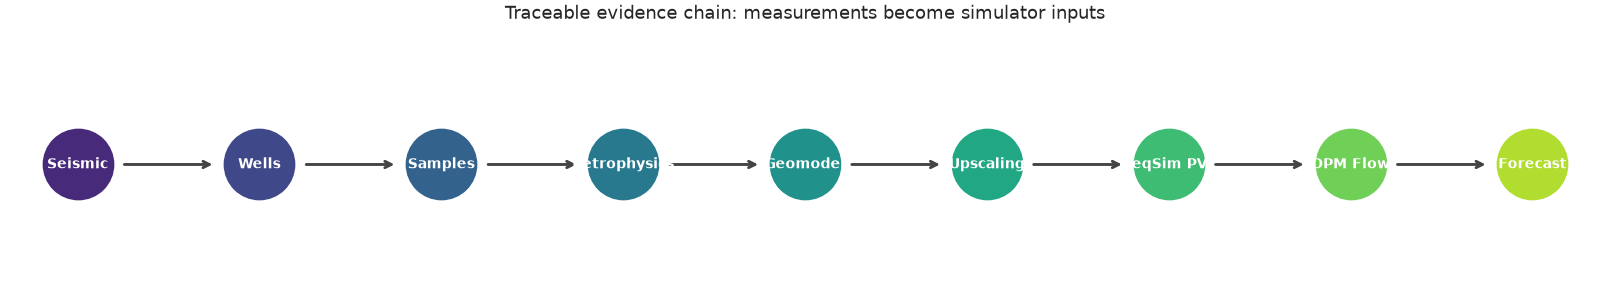

In [3]:
workflow_steps = [
    "Seismic",
    "Wells",
    "Samples",
    "Petrophysics",
    "Geomodel",
    "Upscaling",
    "NeqSim PVT",
    "OPM Flow",
    "Forecast",
]

workflow_figure, workflow_axis = plt.subplots(
    figsize=(14.0, 2.6),
    constrained_layout=True,
)
workflow_axis.set_xlim(-0.4, len(workflow_steps) - 0.6)
workflow_axis.set_ylim(-0.7, 0.7)
workflow_axis.axis("off")

workflow_colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(workflow_steps)))
for step_index, (step_name, step_color) in enumerate(
    zip(workflow_steps, workflow_colors)
):
    workflow_axis.scatter(
        step_index,
        0.0,
        s=2200,
        color=step_color,
        edgecolor="white",
        linewidth=2.0,
        zorder=3,
    )
    workflow_axis.text(
        step_index,
        0.0,
        step_name,
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
        zorder=4,
    )
    if step_index < len(workflow_steps) - 1:
        workflow_axis.annotate(
            "",
            xy=(step_index + 0.76, 0.0),
            xytext=(step_index + 0.24, 0.0),
            arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#444444"},
        )

workflow_axis.set_title(
    "Traceable evidence chain: measurements become simulator inputs",
    pad=10,
)
workflow_path = OUTPUT_DIRECTORY / "workflow_chain.png"
workflow_figure.savefig(workflow_path, dpi=170, bbox_inches="tight")
plt.show()

## 1. Sample and data governance before modelling

A sample is useful only when its identity and conditions survive the handoff. A real project should
track at least sample ID, well, depth, collection method, pressure, temperature, preservation,
laboratory, analysis method, units, uncertainty, quality status and model version.

The synthetic register below includes the main evidence classes. It also separates:

- **measured** values, such as plug porosity or fluid composition;
- **interpreted** values, such as a seismic horizon or log-derived saturation; and
- **modelled** values, such as a geostatistical property between wells.

This prevents a smooth model realization from being mistaken for dense measurement coverage.

In [4]:
sample_register = pd.DataFrame(
    [
        (
            "SEIS-3D-01",
            "seismic",
            "-",
            "-",
            "3-D amplitude volume",
            "interpreted",
        ),
        (
            "BH-01-LAS",
            "wireline",
            "BH-01",
            "2320-2520",
            "GR/RHOB/NPHI/RT",
            "measured",
        ),
        (
            "BH-02-LAS",
            "wireline",
            "BH-02",
            "2320-2520",
            "GR/RHOB/NPHI/RT",
            "measured",
        ),
        (
            "BH-03-LAS",
            "wireline",
            "BH-03",
            "2320-2520",
            "GR/RHOB/NPHI/RT",
            "measured",
        ),
        (
            "BH-04-LAS",
            "wireline",
            "BH-04",
            "2320-2520",
            "GR/RHOB/NPHI/RT",
            "measured",
        ),
        (
            "BH-05-LAS",
            "wireline",
            "BH-05",
            "2320-2520",
            "GR/RHOB/NPHI/RT",
            "measured",
        ),
        (
            "RCAL-SET-01",
            "core plugs",
            "BH-01/03/05",
            "reservoir",
            "phi/k/grain density",
            "measured",
        ),
        (
            "SCAL-SET-01",
            "SCAL plugs",
            "BH-01/03",
            "reservoir",
            "kr/Pc/endpoints",
            "measured",
        ),
        (
            "PVT-DH-01",
            "downhole fluid",
            "BH-03",
            "2412",
            "composition/CCE/DLE",
            "measured",
        ),
        (
            "SEP-REC-01",
            "separator recombination",
            "BH-03",
            "-",
            "separator oil and gas",
            "measured",
        ),
        (
            "FW-01",
            "formation water",
            "BH-02",
            "2448",
            "density/viscosity/salinity",
            "measured",
        ),
        (
            "RFT-SET-01",
            "formation pressure",
            "BH-01/02/04",
            "reservoir",
            "pressure-depth",
            "measured",
        ),
    ],
    columns=[
        "sample_id",
        "class",
        "well",
        "depth_m",
        "content",
        "evidence_type",
    ],
)
sample_register["quality_status"] = "synthetic teaching QA"
display(sample_register)

,sample_id,class,well,depth_m,content,evidence_type,quality_status
0,SEIS-3D-01,seismic,-,-,3-D amplitude volume,interpreted,synthetic teaching QA
1,BH-01-LAS,wireline,BH-01,2320-2520,GR/RHOB/NPHI/RT,measured,synthetic teaching QA
2,BH-02-LAS,wireline,BH-02,2320-2520,GR/RHOB/NPHI/RT,measured,synthetic teaching QA
3,BH-03-LAS,wireline,BH-03,2320-2520,GR/RHOB/NPHI/RT,measured,synthetic teaching QA
4,BH-04-LAS,wireline,BH-04,2320-2520,GR/RHOB/NPHI/RT,measured,synthetic teaching QA
5,BH-05-LAS,wireline,BH-05,2320-2520,GR/RHOB/NPHI/RT,measured,synthetic teaching QA
6,RCAL-SET-01,core plugs,BH-01/03/05,reservoir,phi/k/grain density,measured,synthetic teaching QA
7,SCAL-SET-01,SCAL plugs,BH-01/03,reservoir,kr/Pc/endpoints,measured,synthetic teaching QA
8,PVT-DH-01,downhole fluid,BH-03,2412,composition/CCE/DLE,measured,synthetic teaching QA
9,SEP-REC-01,separator recombination,BH-03,-,separator oil and gas,measured,synthetic teaching QA


## 2. Synthetic seismic survey and structural interpretation

The example generates acoustic impedance with a lower-impedance sandstone interval inside shale.
Normal-incidence reflectivity is

$$
r_i = \frac{Z_{i+1} - Z_i}{Z_{i+1} + Z_i},
$$

where $Z$ is acoustic impedance. Convolution with a Ricker wavelet creates a band-limited synthetic
seismic response. The horizon picker searches for the negative top-reservoir event and the positive
base-reservoir event inside reviewed depth windows.

In a real workflow this section would read processed depth-domain SEG-Y, preserve trace headers,
apply the interpretation version and carry velocity-model uncertainty into the structural ensemble.

In [5]:
seismic_nx = 40
seismic_ny = 32
seismic_nz = 180

seismic_x_m = np.linspace(25.0, 1975.0, seismic_nx)
seismic_y_m = np.linspace(25.0, 1575.0, seismic_ny)
seismic_depth_m = np.linspace(2320.0, 2520.0, seismic_nz)
seismic_x_grid_m, seismic_y_grid_m = np.meshgrid(
    seismic_x_m,
    seismic_y_m,
)

regional_dip_m = (
    0.012 * seismic_x_grid_m
    + 0.006 * seismic_y_grid_m
)
structural_high_m = -38.0 * np.exp(
    -(
        (seismic_x_grid_m - 720.0) ** 2 / (2.0 * 430.0**2)
        + (seismic_y_grid_m - 760.0) ** 2 / (2.0 * 360.0**2)
    )
)
fault_throw_m = np.where(seismic_x_grid_m > 1120.0, 16.0, 0.0)
true_top_depth_m = 2400.0 + regional_dip_m + structural_high_m + fault_throw_m

channel_axis_m = 760.0 + 180.0 * np.sin(seismic_x_grid_m / 420.0)
channel_distance_m = np.abs(seismic_y_grid_m - channel_axis_m)
channel_factor = np.exp(-(channel_distance_m / 210.0) ** 2)
true_thickness_m = 24.0 + 18.0 * channel_factor
true_base_depth_m = true_top_depth_m + true_thickness_m

depth_cube_m = seismic_depth_m[None, None, :]
reservoir_mask = (
    (depth_cube_m >= true_top_depth_m[:, :, None])
    & (depth_cube_m <= true_base_depth_m[:, :, None])
)

shale_impedance = 9.2e6
sand_impedance = 7.1e6
acoustic_impedance = np.where(
    reservoir_mask,
    sand_impedance,
    shale_impedance,
)
acoustic_impedance *= 1.0 + 0.012 * random_generator.normal(
    size=acoustic_impedance.shape
)

impedance_above = acoustic_impedance[:, :, :-1]
impedance_below = acoustic_impedance[:, :, 1:]
reflectivity = np.zeros_like(acoustic_impedance)
reflectivity[:, :, 1:] = (
    (impedance_below - impedance_above)
    / (impedance_below + impedance_above)
)

wavelet_sample = np.linspace(-0.05, 0.05, 41)
dominant_frequency_hz = 28.0
ricker_argument = np.pi * dominant_frequency_hz * wavelet_sample
ricker_wavelet = (
    1.0 - 2.0 * ricker_argument**2
) * np.exp(-ricker_argument**2)

seismic_cube = fftconvolve(
    reflectivity,
    ricker_wavelet[None, None, :],
    mode="same",
    axes=2,
)
seismic_cube += 0.018 * random_generator.normal(size=seismic_cube.shape)

top_window = (
    (seismic_depth_m >= 2350.0)
    & (seismic_depth_m <= 2460.0)
)
base_window = (
    (seismic_depth_m >= 2390.0)
    & (seismic_depth_m <= 2510.0)
)
interpreted_top_depth_m = seismic_depth_m[top_window][
    np.argmin(seismic_cube[:, :, top_window], axis=2)
]
interpreted_base_depth_m = seismic_depth_m[base_window][
    np.argmax(seismic_cube[:, :, base_window], axis=2)
]
interpreted_thickness_m = np.clip(
    interpreted_base_depth_m - interpreted_top_depth_m,
    12.0,
    55.0,
)

top_pick_error_m = interpreted_top_depth_m - true_top_depth_m
seismic_qc = pd.DataFrame(
    {
        "metric": [
            "traces",
            "samples per trace",
            "top-pick mean error",
            "top-pick RMSE",
            "interpreted thickness mean",
        ],
        "value": [
            seismic_nx * seismic_ny,
            seismic_nz,
            top_pick_error_m.mean(),
            np.sqrt(np.mean(top_pick_error_m**2)),
            interpreted_thickness_m.mean(),
        ],
        "unit": ["count", "count", "m", "m", "m"],
    }
)
display(seismic_qc)

,metric,value,unit
0,traces,1280.000000,count
1,samples per trace,180.000000,count
2,top-pick mean error,0.596443,m
3,top-pick RMSE,1.427443,m
4,interpreted thickness mean,28.145915,m


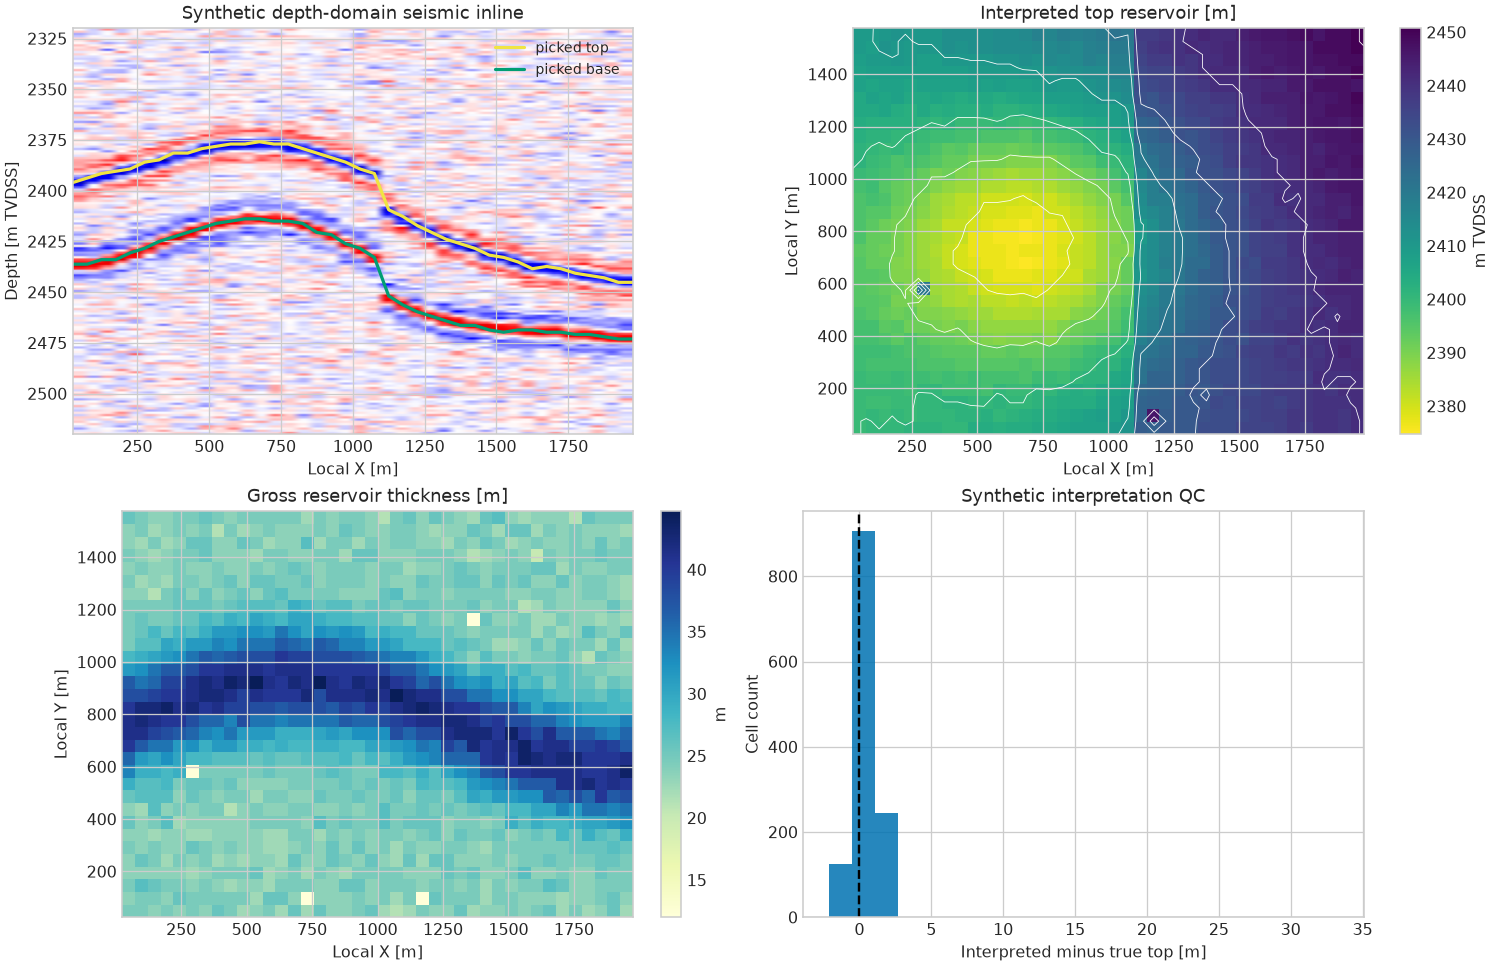

In [6]:
central_inline_index = seismic_ny // 2

seismic_figure, seismic_axes = plt.subplots(
    2,
    2,
    figsize=(13.0, 8.4),
    constrained_layout=True,
)

seismic_axes[0, 0].imshow(
    seismic_cube[central_inline_index].T,
    cmap="seismic",
    aspect="auto",
    extent=[
        seismic_x_m.min(),
        seismic_x_m.max(),
        seismic_depth_m.max(),
        seismic_depth_m.min(),
    ],
    vmin=-0.22,
    vmax=0.22,
)
seismic_axes[0, 0].plot(
    seismic_x_m,
    interpreted_top_depth_m[central_inline_index],
    color="#F0E442",
    linewidth=2.0,
    label="picked top",
)
seismic_axes[0, 0].plot(
    seismic_x_m,
    interpreted_base_depth_m[central_inline_index],
    color="#009E73",
    linewidth=2.0,
    label="picked base",
)
seismic_axes[0, 0].set_xlabel("Local X [m]")
seismic_axes[0, 0].set_ylabel("Depth [m TVDSS]")
seismic_axes[0, 0].set_title("Synthetic depth-domain seismic inline")
seismic_axes[0, 0].legend()

top_image = seismic_axes[0, 1].imshow(
    interpreted_top_depth_m,
    origin="lower",
    extent=[
        seismic_x_m.min(),
        seismic_x_m.max(),
        seismic_y_m.min(),
        seismic_y_m.max(),
    ],
    cmap="viridis_r",
)
seismic_axes[0, 1].contour(
    seismic_x_grid_m,
    seismic_y_grid_m,
    interpreted_top_depth_m,
    colors="white",
    linewidths=0.5,
)
seismic_axes[0, 1].set_xlabel("Local X [m]")
seismic_axes[0, 1].set_ylabel("Local Y [m]")
seismic_axes[0, 1].set_title("Interpreted top reservoir [m]")
seismic_figure.colorbar(top_image, ax=seismic_axes[0, 1], label="m TVDSS")

thickness_image = seismic_axes[1, 0].imshow(
    interpreted_thickness_m,
    origin="lower",
    extent=[
        seismic_x_m.min(),
        seismic_x_m.max(),
        seismic_y_m.min(),
        seismic_y_m.max(),
    ],
    cmap="YlGnBu",
)
seismic_axes[1, 0].set_xlabel("Local X [m]")
seismic_axes[1, 0].set_ylabel("Local Y [m]")
seismic_axes[1, 0].set_title("Gross reservoir thickness [m]")
seismic_figure.colorbar(
    thickness_image,
    ax=seismic_axes[1, 0],
    label="m",
)

seismic_axes[1, 1].hist(
    top_pick_error_m.ravel(),
    bins=22,
    color="#0072B2",
    alpha=0.85,
)
seismic_axes[1, 1].axvline(0.0, color="black", linestyle="--")
seismic_axes[1, 1].set_xlabel("Interpreted minus true top [m]")
seismic_axes[1, 1].set_ylabel("Cell count")
seismic_axes[1, 1].set_title("Synthetic interpretation QC")

seismic_plot_path = OUTPUT_DIRECTORY / "seismic_and_horizons.png"
seismic_figure.savefig(seismic_plot_path, dpi=170)
plt.show()

### SEG-Y handoff

The compact file below is not intended to mimic every acquisition or processing header. It proves
the file contract: amplitudes are written as IEEE floats, trace coordinates and inline/crossline
indices are retained, and the complete trace matrix is recovered without numerical drift.

In [7]:
segy_path = OUTPUT_DIRECTORY / "synthetic_reservoir_depth.sgy"
segy_specification = segyio.spec()
segy_specification.format = 5
segy_specification.samples = seismic_depth_m
segy_specification.tracecount = seismic_nx * seismic_ny

with segyio.create(str(segy_path), segy_specification) as segy_file:
    trace_index = 0
    for y_index in range(seismic_ny):
        for x_index in range(seismic_nx):
            segy_file.trace[trace_index] = seismic_cube[
                y_index,
                x_index,
                :,
            ].astype(np.float32)
            segy_file.header[trace_index] = {
                segyio.TraceField.INLINE_3D: y_index + 1,
                segyio.TraceField.CROSSLINE_3D: x_index + 1,
                segyio.TraceField.SourceX: int(seismic_x_m[x_index]),
                segyio.TraceField.SourceY: int(seismic_y_m[y_index]),
            }
            trace_index += 1

with segyio.open(str(segy_path), "r", ignore_geometry=True) as segy_file:
    recovered_traces = np.asarray(segy_file.trace.raw[:], dtype=float)
    recovered_source_x = np.asarray(
        segy_file.attributes(segyio.TraceField.SourceX)[:],
        dtype=int,
    )
    recovered_source_y = np.asarray(
        segy_file.attributes(segyio.TraceField.SourceY)[:],
        dtype=int,
    )

expected_traces = seismic_cube.reshape(
    seismic_nx * seismic_ny,
    seismic_nz,
)
segy_audit = pd.DataFrame(
    {
        "check": [
            "trace count",
            "sample count",
            "maximum amplitude difference",
            "unique X coordinates",
            "unique Y coordinates",
            "file size",
        ],
        "value": [
            recovered_traces.shape[0],
            recovered_traces.shape[1],
            np.max(np.abs(recovered_traces - expected_traces)),
            np.unique(recovered_source_x).size,
            np.unique(recovered_source_y).size,
            segy_path.stat().st_size / 1.0e6,
        ],
        "unit": ["count", "count", "-", "count", "count", "MB"],
    }
)
display(segy_audit)
print(f"SEG-Y file: {segy_path}")

,check,value,unit
0,trace count,1.280000e+03,count
1,sample count,1.800000e+02,count
2,maximum amplitude difference,7.449628e-09,-
3,unique X coordinates,4.000000e+01,count
4,unique Y coordinates,3.200000e+01,count
5,file size,1.232400e+00,MB


SEG-Y file: subsurface_to_opm_outputs/synthetic_reservoir_depth.sgy


## 3. Wells, logs and LAS files

Five synthetic appraisal wells condition the petrophysical model. The curves represent:

- gamma ray (`GR`) for shale-volume screening;
- bulk density (`RHOB`) and neutron porosity (`NPHI`) for porosity;
- deep resistivity (`RT`) for saturation; and
- interpreted reservoir top/base for zonation.

Noise and occasional poor-hole intervals are included. The interpretation uses explicit QC masks
instead of silently filling every value.

In [8]:
well_locations = pd.DataFrame(
    [
        ("BH-01", 330.0, 360.0),
        ("BH-02", 690.0, 1180.0),
        ("BH-03", 980.0, 720.0),
        ("BH-04", 1450.0, 340.0),
        ("BH-05", 1690.0, 1240.0),
    ],
    columns=["well", "x_m", "y_m"],
)


def nearest_map_value(map_values, x_m, y_m):
    x_index = int(np.argmin(np.abs(seismic_x_m - x_m)))
    y_index = int(np.argmin(np.abs(seismic_y_m - y_m)))
    return float(map_values[y_index, x_index])


well_log_frames = []
well_zone_rows = []
for well_index, well_row in well_locations.iterrows():
    well_name = well_row["well"]
    well_x_m = well_row["x_m"]
    well_y_m = well_row["y_m"]
    well_top_m = nearest_map_value(true_top_depth_m, well_x_m, well_y_m)
    well_base_m = nearest_map_value(true_base_depth_m, well_x_m, well_y_m)
    well_depth_m = np.arange(2320.0, 2520.5, 0.5)
    in_reservoir = (
        (well_depth_m >= well_top_m)
        & (well_depth_m <= well_base_m)
    )
    local_channel = np.exp(
        -(
            (
                well_y_m
                - (760.0 + 180.0 * np.sin(well_x_m / 420.0))
            )
            / 210.0
        )
        ** 2
    )
    clean_sand_probability = 0.45 + 0.45 * local_channel
    vertical_texture = gaussian_filter(
        random_generator.normal(size=well_depth_m.size),
        sigma=2.2,
    )
    sand_indicator = (
        in_reservoir
        & (
            vertical_texture
            > np.quantile(
                vertical_texture[in_reservoir],
                1.0 - clean_sand_probability,
            )
        )
    )
    gamma_ray_api = np.where(sand_indicator, 38.0, 108.0)
    gamma_ray_api += random_generator.normal(0.0, 6.0, well_depth_m.size)
    density_g_cm3 = np.where(sand_indicator, 2.19, 2.54)
    density_g_cm3 += random_generator.normal(0.0, 0.025, well_depth_m.size)
    neutron_fraction = np.where(sand_indicator, 0.24, 0.10)
    neutron_fraction += random_generator.normal(0.0, 0.018, well_depth_m.size)
    water_zone = well_depth_m >= BASE_OWC_DEPTH_M
    resistivity_ohm_m = np.where(
        sand_indicator & ~water_zone,
        42.0,
        np.where(sand_indicator & water_zone, 4.5, 2.2),
    )
    resistivity_ohm_m *= np.exp(
        random_generator.normal(0.0, 0.12, well_depth_m.size)
    )
    caliper_in = 8.5 + random_generator.normal(
        0.0,
        0.12,
        well_depth_m.size,
    )
    if well_index in [1, 4]:
        bad_hole = (
            (well_depth_m > well_top_m + 5.0)
            & (well_depth_m < well_top_m + 8.0)
        )
        caliper_in[bad_hole] += 2.2
        density_g_cm3[bad_hole] -= 0.12

    well_frame = pd.DataFrame(
        {
            "well": well_name,
            "depth_m": well_depth_m,
            "GR_API": gamma_ray_api,
            "RHOB_g_cm3": density_g_cm3,
            "NPHI_fraction": neutron_fraction,
            "RT_ohm_m": resistivity_ohm_m,
            "CALI_in": caliper_in,
            "true_sand": sand_indicator,
        }
    )
    well_log_frames.append(well_frame)
    well_zone_rows.append(
        {
            "well": well_name,
            "top_m": well_top_m,
            "base_m": well_base_m,
            "gross_m": well_base_m - well_top_m,
        }
    )

well_logs = pd.concat(well_log_frames, ignore_index=True)
well_zones = pd.DataFrame(well_zone_rows)
display(well_locations)
display(well_zones)

,well,x_m,y_m
0,BH-01,330.0,360.0
1,BH-02,690.0,1180.0
2,BH-03,980.0,720.0
3,BH-04,1450.0,340.0
4,BH-05,1690.0,1240.0


,well,top_m,base_m,gross_m
0,BH-01,2392.083259,2416.131768,24.048509
1,BH-02,2395.703601,2424.842489,29.138889
2,BH-03,2384.327640,2417.918346,33.590706
3,BH-04,2430.274426,2454.843939,24.569513
4,BH-05,2442.049094,2466.054249,24.005155


In [9]:
las_paths = []
las_roundtrip_rows = []
for well_name, well_frame in well_logs.groupby("well", sort=True):
    las_file = lasio.LASFile()
    las_file.well.WELL = lasio.HeaderItem(
        mnemonic="WELL",
        value=well_name,
        descr="Synthetic teaching well",
    )
    las_file.append_curve(
        "DEPT",
        well_frame["depth_m"].to_numpy(),
        unit="M",
        descr="Measured depth/TVDSS for vertical synthetic well",
    )
    for curve_name, unit, description in [
        ("GR_API", "API", "Gamma ray"),
        ("RHOB_g_cm3", "G/C3", "Bulk density"),
        ("NPHI_fraction", "V/V", "Neutron porosity"),
        ("RT_ohm_m", "OHMM", "Deep resistivity"),
        ("CALI_in", "IN", "Caliper"),
    ]:
        las_file.append_curve(
            curve_name,
            well_frame[curve_name].to_numpy(),
            unit=unit,
            descr=description,
        )
    las_path = OUTPUT_DIRECTORY / f"{well_name}.las"
    las_file.write(str(las_path), version=2.0)
    recovered_las = lasio.read(str(las_path))
    las_paths.append(las_path)
    las_roundtrip_rows.append(
        {
            "well": well_name,
            "curves": len(recovered_las.curves),
            "samples": len(recovered_las.index),
            "depth_min_m": recovered_las.index.min(),
            "depth_max_m": recovered_las.index.max(),
            "file_kB": las_path.stat().st_size / 1000.0,
        }
    )

las_roundtrip_audit = pd.DataFrame(las_roundtrip_rows)
display(las_roundtrip_audit)

,well,curves,samples,depth_min_m,depth_max_m,file_kB
0,BH-01,6,401,2320.0,2520.0,28.095
1,BH-02,6,401,2320.0,2520.0,28.095
2,BH-03,6,401,2320.0,2520.0,28.095
3,BH-04,6,401,2320.0,2520.0,28.095
4,BH-05,6,401,2320.0,2520.0,28.095


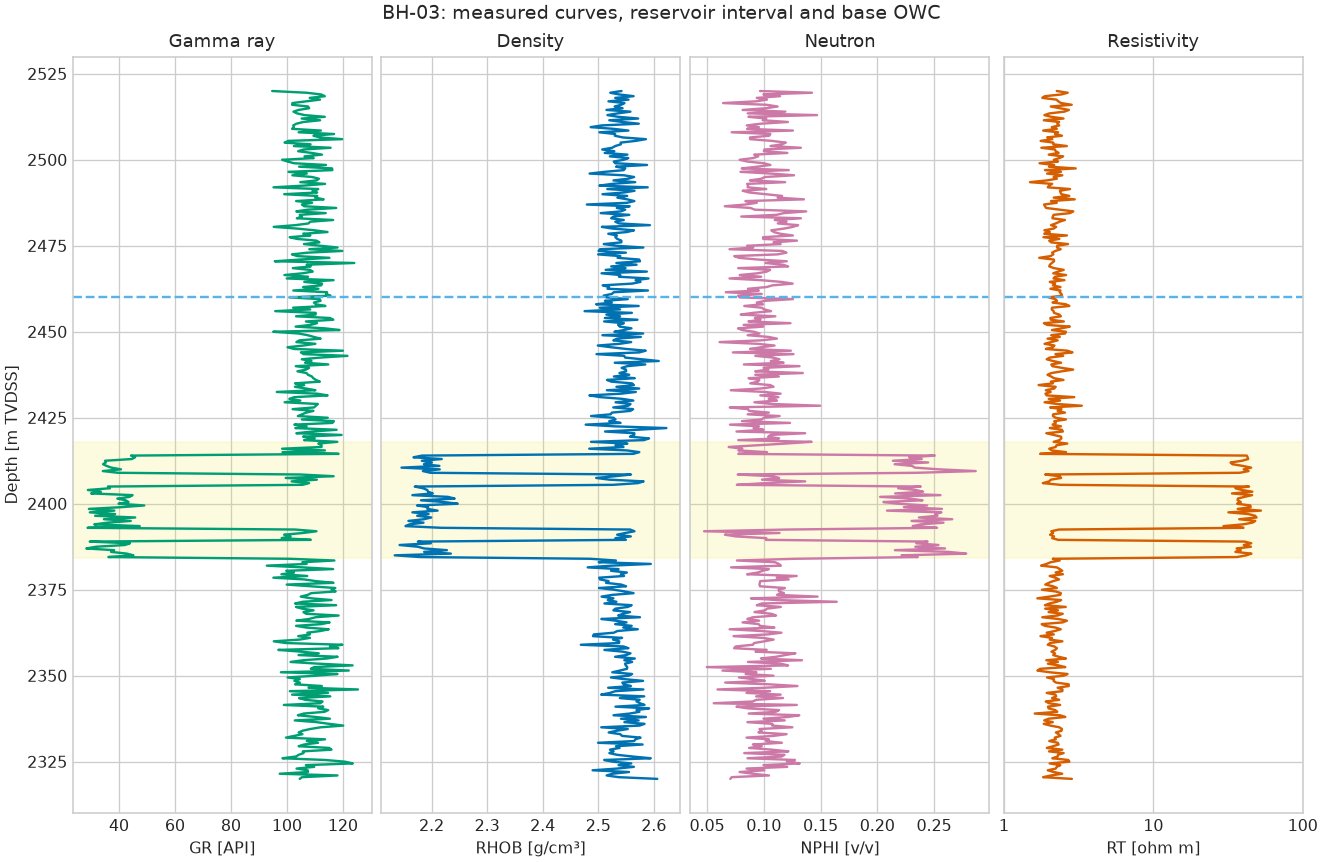

In [10]:
display_well = "BH-03"
display_log = well_logs.loc[well_logs["well"] == display_well].copy()
display_zone = well_zones.loc[well_zones["well"] == display_well].iloc[0]

log_figure, log_axes = plt.subplots(
    1,
    4,
    figsize=(11.5, 7.5),
    sharey=True,
    constrained_layout=True,
)

log_axes[0].plot(display_log["GR_API"], display_log["depth_m"], color="#009E73")
log_axes[0].set_xlabel("GR [API]")
log_axes[0].set_ylabel("Depth [m TVDSS]")
log_axes[0].set_title("Gamma ray")

log_axes[1].plot(
    display_log["RHOB_g_cm3"],
    display_log["depth_m"],
    color="#0072B2",
    label="RHOB",
)
log_axes[1].set_xlabel("RHOB [g/cm³]")
log_axes[1].set_title("Density")

log_axes[2].plot(
    display_log["NPHI_fraction"],
    display_log["depth_m"],
    color="#CC79A7",
)
log_axes[2].set_xlabel("NPHI [v/v]")
log_axes[2].set_title("Neutron")

log_axes[3].semilogx(
    display_log["RT_ohm_m"],
    display_log["depth_m"],
    color="#D55E00",
)
log_axes[3].set_xlabel("RT [ohm m]")
log_axes[3].set_title("Resistivity")
log_axes[3].set_xlim(1.0, 100.0)
log_axes[3].set_xticks([1.0, 10.0, 100.0])
log_axes[3].set_xticklabels(["1", "10", "100"])
log_axes[3].xaxis.set_minor_formatter(NullFormatter())

for log_axis in log_axes:
    log_axis.axhspan(
        display_zone["top_m"],
        display_zone["base_m"],
        color="#F0E442",
        alpha=0.17,
    )
    log_axis.axhline(BASE_OWC_DEPTH_M, color="#56B4E9", linestyle="--")
    log_axis.invert_yaxis()

log_figure.suptitle(
    f"{display_well}: measured curves, reservoir interval and base OWC",
)
log_plot_path = OUTPUT_DIRECTORY / "synthetic_well_logs.png"
log_figure.savefig(log_plot_path, dpi=170)
plt.show()

## 4. Rock samples: RCAL calibration

Core plugs anchor log-derived porosity and permeability. The synthetic RCAL set contains helium
porosity, gas permeability and grain density. In a real study, gas permeability would be corrected
for slippage and stress, and the core/log depth shift would be reviewed before regression.

The permeability transform is fitted in logarithmic space:

$$
\log_{10} k = a_k + b_k \phi,
$$

where $k$ is permeability in mD and $\phi$ is fractional porosity. The relationship is applied only
inside the sampled facies and porosity range; extrapolation is explicitly clipped later.

In [11]:
core_rows = []
core_sample_number = 1
for well_name in ["BH-01", "BH-03", "BH-05"]:
    well_frame = well_logs.loc[
        (well_logs["well"] == well_name)
        & well_logs["true_sand"]
    ].copy()
    sampled_indices = np.linspace(
        0,
        len(well_frame) - 1,
        8,
        dtype=int,
    )
    for sampled_index in sampled_indices:
        log_row = well_frame.iloc[sampled_index]
        density_porosity = np.clip(
            (2.65 - log_row["RHOB_g_cm3"]) / (2.65 - 0.82),
            0.03,
            0.36,
        )
        core_porosity = np.clip(
            density_porosity + random_generator.normal(0.0, 0.008),
            0.05,
            0.34,
        )
        log_permeability = (
            -2.0
            + 19.0 * core_porosity
            + random_generator.normal(0.0, 0.20)
        )
        core_rows.append(
            {
                "sample_id": f"RCAL-{core_sample_number:03d}",
                "well": well_name,
                "depth_m": log_row["depth_m"],
                "helium_porosity_fraction": core_porosity,
                "gas_permeability_mD": 10.0**log_permeability,
                "grain_density_g_cm3": (
                    2.65 + random_generator.normal(0.0, 0.015)
                ),
                "confining_stress_bar": 200.0,
            }
        )
        core_sample_number += 1

core_samples = pd.DataFrame(core_rows)
core_slope, core_intercept = np.polyfit(
    core_samples["helium_porosity_fraction"],
    np.log10(core_samples["gas_permeability_mD"]),
    deg=1,
)
core_logk_prediction = (
    core_intercept
    + core_slope * core_samples["helium_porosity_fraction"].to_numpy()
)
core_logk_observed = np.log10(
    core_samples["gas_permeability_mD"].to_numpy()
)
core_residual_sum_squares = np.sum(
    (core_logk_observed - core_logk_prediction) ** 2
)
core_total_sum_squares = np.sum(
    (core_logk_observed - core_logk_observed.mean()) ** 2
)
core_r2 = 1.0 - core_residual_sum_squares / core_total_sum_squares

core_fit = pd.DataFrame(
    {
        "parameter": ["intercept", "porosity coefficient", "R²", "samples"],
        "value": [
            core_intercept,
            core_slope,
            core_r2,
            len(core_samples),
        ],
        "unit": ["log10(mD)", "log10(mD)/fraction", "-", "count"],
    }
)
display(core_samples.head(10))
display(core_fit)

,sample_id,well,depth_m,helium_porosity_fraction,gas_permeability_mD,grain_density_g_cm3,confining_stress_bar
0,RCAL-001,BH-01,2392.5,0.231608,572.530512,2.667533,200.0
1,RCAL-002,BH-01,2394.0,0.244174,516.608805,2.639016,200.0
2,RCAL-003,BH-01,2395.5,0.259671,748.513167,2.623560,200.0
3,RCAL-004,BH-01,2397.0,0.248890,539.105526,2.641543,200.0
4,RCAL-005,BH-01,2409.0,0.243730,497.679050,2.642647,200.0
5,RCAL-006,BH-01,2410.5,0.261609,2055.726305,2.636873,200.0
6,RCAL-007,BH-01,2412.0,0.236797,203.410837,2.655761,200.0
7,RCAL-008,BH-01,2416.0,0.244225,952.695922,2.648025,200.0
8,RCAL-009,BH-03,2384.5,0.262913,642.835949,2.643073,200.0
9,RCAL-010,BH-03,2387.5,0.256964,2353.718945,2.640743,200.0


,parameter,value,unit
0,intercept,-1.858916,log10(mD)
1,porosity coefficient,18.606994,log10(mD)/fraction
2,R²,0.815851,-
3,samples,24.000000,count


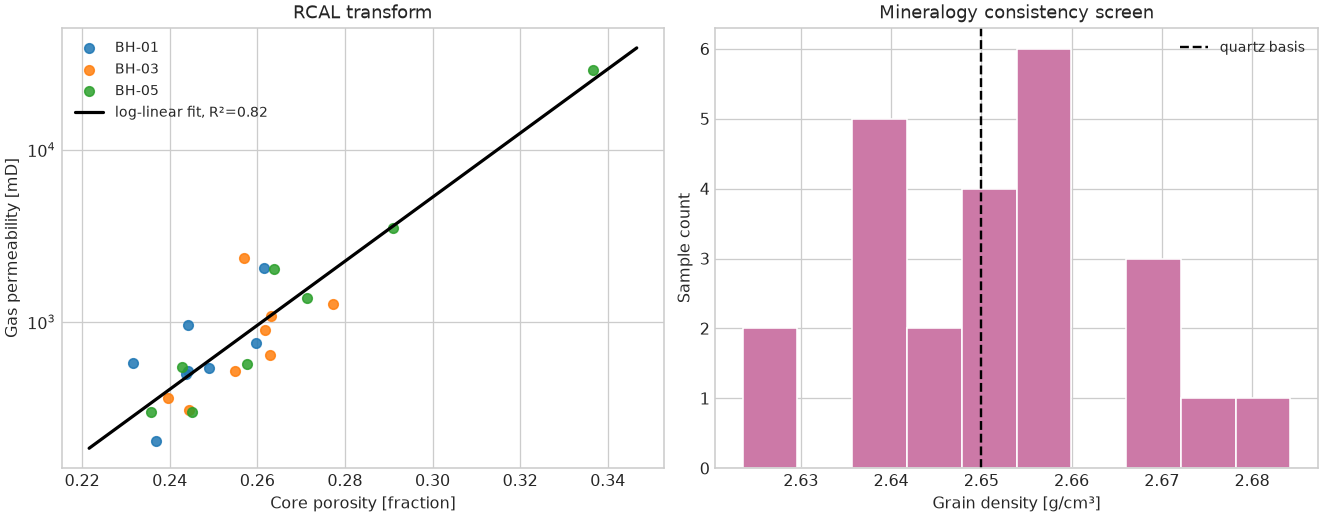

In [12]:
porosity_axis = np.linspace(
    core_samples["helium_porosity_fraction"].min() - 0.01,
    core_samples["helium_porosity_fraction"].max() + 0.01,
    100,
)
permeability_fit = 10.0 ** (
    core_intercept + core_slope * porosity_axis
)

core_figure, core_axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.5),
    constrained_layout=True,
)
for well_name, sample_frame in core_samples.groupby("well"):
    core_axes[0].scatter(
        sample_frame["helium_porosity_fraction"],
        sample_frame["gas_permeability_mD"],
        label=well_name,
        alpha=0.85,
    )
core_axes[0].plot(
    porosity_axis,
    permeability_fit,
    color="black",
    linewidth=2.0,
    label=f"log-linear fit, R²={core_r2:.2f}",
)
core_axes[0].set_yscale("log")
core_axes[0].set_xlabel("Core porosity [fraction]")
core_axes[0].set_ylabel("Gas permeability [mD]")
core_axes[0].set_title("RCAL transform")
core_axes[0].legend()

core_axes[1].hist(
    core_samples["grain_density_g_cm3"],
    bins=10,
    color="#CC79A7",
    edgecolor="white",
)
core_axes[1].axvline(2.65, color="black", linestyle="--", label="quartz basis")
core_axes[1].set_xlabel("Grain density [g/cm³]")
core_axes[1].set_ylabel("Sample count")
core_axes[1].set_title("Mineralogy consistency screen")
core_axes[1].legend()

core_plot_path = OUTPUT_DIRECTORY / "core_calibration.png"
core_figure.savefig(core_plot_path, dpi=170)
plt.show()

## 5. Transparent petrophysical interpretation

For the synthetic clean-sand case:

$$
V_\mathrm{sh} =
\operatorname{clip}\left(
\frac{GR-GR_\mathrm{clean}}{GR_\mathrm{shale}-GR_\mathrm{clean}},
0,1
\right),
$$

$$
\phi_D =
\frac{\rho_\mathrm{ma}-\rho_b}
{\rho_\mathrm{ma}-\rho_f},
$$

and Archie's equation is

$$
S_w =
\left(
\frac{a R_w}{R_t \phi^m}
\right)^{1/n}.
$$

Here $a=1$, $m=2$, $n=2$ and $R_w=0.08$ ohm m. Archie is not appropriate for
conductive shaly sands without a shale-aware saturation model. The code therefore reports shale
volume and limits net pay to relatively clean intervals.

In [13]:
GR_CLEAN_API = 30.0
GR_SHALE_API = 120.0
MATRIX_DENSITY_G_CM3 = 2.65
FLUID_DENSITY_G_CM3 = 0.82
ARCHIE_A = 1.0
ARCHIE_M = 2.0
ARCHIE_N = 2.0
FORMATION_WATER_RESISTIVITY_OHM_M = 0.08

interpreted_logs = well_logs.copy()
interpreted_logs["good_hole"] = interpreted_logs["CALI_in"] < 9.5
interpreted_logs["VSH_fraction"] = np.clip(
    (
        interpreted_logs["GR_API"] - GR_CLEAN_API
    )
    / (GR_SHALE_API - GR_CLEAN_API),
    0.0,
    1.0,
)
interpreted_logs["PHID_fraction"] = np.clip(
    (
        MATRIX_DENSITY_G_CM3
        - interpreted_logs["RHOB_g_cm3"]
    )
    / (MATRIX_DENSITY_G_CM3 - FLUID_DENSITY_G_CM3),
    0.0,
    0.40,
)
interpreted_logs["PHIE_fraction"] = np.clip(
    (
        0.65 * interpreted_logs["PHID_fraction"]
        + 0.35 * interpreted_logs["NPHI_fraction"]
    )
    * (1.0 - 0.45 * interpreted_logs["VSH_fraction"]),
    0.01,
    0.35,
)
archie_denominator = (
    interpreted_logs["RT_ohm_m"]
    * interpreted_logs["PHIE_fraction"] ** ARCHIE_M
)
interpreted_logs["SW_fraction"] = np.clip(
    (
        ARCHIE_A
        * FORMATION_WATER_RESISTIVITY_OHM_M
        / archie_denominator
    )
    ** (1.0 / ARCHIE_N),
    0.05,
    1.0,
)
interpreted_logs["net_pay"] = (
    interpreted_logs["good_hole"]
    & (interpreted_logs["VSH_fraction"] <= 0.40)
    & (interpreted_logs["PHIE_fraction"] >= 0.12)
    & (interpreted_logs["SW_fraction"] <= 0.60)
)
interpreted_logs["PERM_mD"] = np.clip(
    10.0
    ** (
        core_intercept
        + core_slope * interpreted_logs["PHIE_fraction"].to_numpy()
    ),
    0.05,
    5000.0,
)

zone_lookup = well_zones.set_index("well")
interpreted_logs["in_reservoir"] = [
    (
        row.depth_m >= zone_lookup.loc[row.well, "top_m"]
        and row.depth_m <= zone_lookup.loc[row.well, "base_m"]
    )
    for row in interpreted_logs.itertuples()
]

petrophysical_summary_rows = []
for well_name, well_frame in interpreted_logs.groupby("well"):
    reservoir_frame = well_frame.loc[well_frame["in_reservoir"]]
    sample_step_m = float(np.median(np.diff(reservoir_frame["depth_m"])))
    petrophysical_summary_rows.append(
        {
            "well": well_name,
            "gross_m": len(reservoir_frame) * sample_step_m,
            "net_pay_m": reservoir_frame["net_pay"].sum() * sample_step_m,
            "NTG_fraction": reservoir_frame["net_pay"].mean(),
            "mean_PHIE_fraction": reservoir_frame.loc[
                reservoir_frame["net_pay"],
                "PHIE_fraction",
            ].mean(),
            "geometric_mean_perm_mD": np.exp(
                np.log(
                    reservoir_frame.loc[
                        reservoir_frame["net_pay"],
                        "PERM_mD",
                    ]
                ).mean()
            ),
            "mean_SW_fraction": reservoir_frame.loc[
                reservoir_frame["net_pay"],
                "SW_fraction",
            ].mean(),
        }
    )

petrophysical_summary = pd.DataFrame(petrophysical_summary_rows)
display(petrophysical_summary)

,well,gross_m,net_pay_m,NTG_fraction,mean_PHIE_fraction,geometric_mean_perm_mD,mean_SW_fraction
0,BH-01,24.0,11.0,0.458333,0.238267,375.425271,0.182694
1,BH-02,29.0,15.0,0.517241,0.236629,349.970626,0.182978
2,BH-03,33.5,23.0,0.686567,0.236988,355.395138,0.188849
3,BH-04,24.5,11.5,0.469388,0.239242,391.433069,0.182539
4,BH-05,24.0,7.0,0.291667,0.234908,325.105150,0.238829


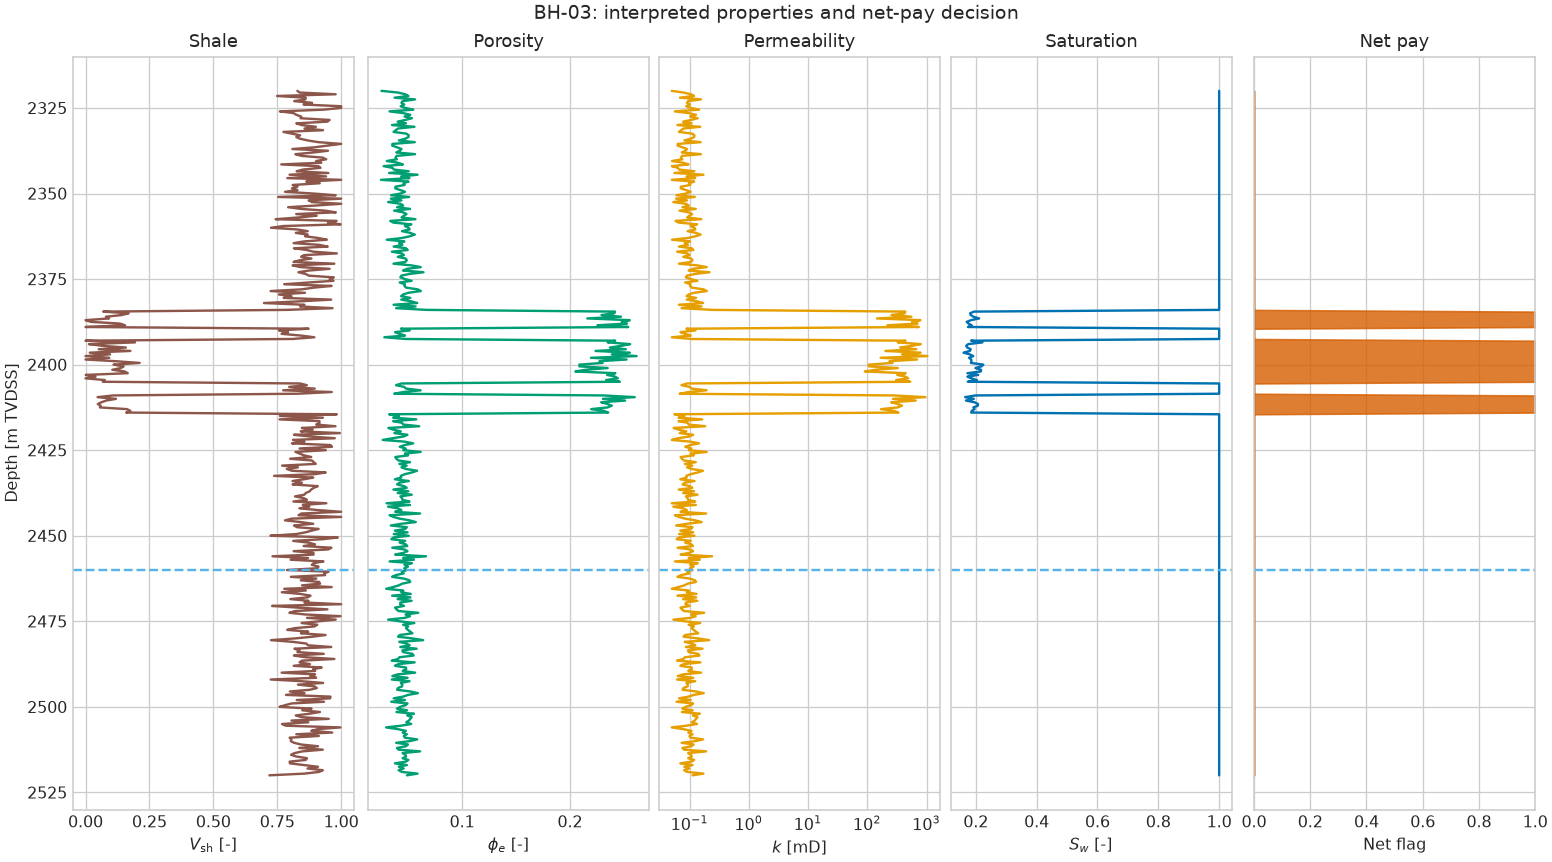

In [14]:
interpreted_display = interpreted_logs.loc[
    interpreted_logs["well"] == display_well
].copy()

petrophysics_figure, petrophysics_axes = plt.subplots(
    1,
    5,
    figsize=(13.5, 7.5),
    sharey=True,
    constrained_layout=True,
)
petrophysics_axes[0].plot(
    interpreted_display["VSH_fraction"],
    interpreted_display["depth_m"],
    color="#8C564B",
)
petrophysics_axes[0].set_xlabel("$V_\\mathrm{sh}$ [-]")
petrophysics_axes[0].set_ylabel("Depth [m TVDSS]")
petrophysics_axes[0].set_title("Shale")

petrophysics_axes[1].plot(
    interpreted_display["PHIE_fraction"],
    interpreted_display["depth_m"],
    color="#009E73",
)
petrophysics_axes[1].set_xlabel("$\\phi_e$ [-]")
petrophysics_axes[1].set_title("Porosity")

petrophysics_axes[2].semilogx(
    interpreted_display["PERM_mD"],
    interpreted_display["depth_m"],
    color="#E69F00",
)
petrophysics_axes[2].set_xlabel("$k$ [mD]")
petrophysics_axes[2].set_title("Permeability")

petrophysics_axes[3].plot(
    interpreted_display["SW_fraction"],
    interpreted_display["depth_m"],
    color="#0072B2",
)
petrophysics_axes[3].set_xlabel("$S_w$ [-]")
petrophysics_axes[3].set_title("Saturation")

petrophysics_axes[4].fill_betweenx(
    interpreted_display["depth_m"],
    0.0,
    interpreted_display["net_pay"].astype(float),
    color="#D55E00",
    alpha=0.8,
)
petrophysics_axes[4].set_xlim(0.0, 1.0)
petrophysics_axes[4].set_xlabel("Net flag")
petrophysics_axes[4].set_title("Net pay")

for petrophysics_axis in petrophysics_axes:
    petrophysics_axis.axhline(
        BASE_OWC_DEPTH_M,
        color="#56B4E9",
        linestyle="--",
    )
    petrophysics_axis.invert_yaxis()

petrophysics_figure.suptitle(
    f"{display_well}: interpreted properties and net-pay decision",
)
petrophysics_plot_path = OUTPUT_DIRECTORY / "petrophysical_interpretation.png"
petrophysics_figure.savefig(petrophysics_plot_path, dpi=170)
plt.show()

## 6. SCAL samples: saturation functions and capillary pressure

Six synthetic waterflood plugs provide irreducible water saturation $S_{wc}$, residual oil
saturation $S_{orw}$, Corey exponents and endpoints. Effective water saturation is

$$
S_w^* =
\operatorname{clip}\left(
\frac{S_w-S_{wc}}{1-S_{wc}-S_{orw}},
0,1
\right).
$$

The water-oil relative permeabilities are represented by

$$
k_{rw}=k_{rw,\mathrm{end}}(S_w^*)^{n_w},
\qquad
k_{ro}=k_{ro,\mathrm{end}}(1-S_w^*)^{n_o}.
$$

This is an educational parameterization. Real SCAL interpretation must retain wettability,
restoration, stress, saturation history, displacement direction, rate and capillary-end effects.

In [15]:
scal_samples = pd.DataFrame(
    {
        "sample_id": [f"SCAL-{index:02d}" for index in range(1, 7)],
        "well": ["BH-01", "BH-01", "BH-03", "BH-03", "BH-05", "BH-05"],
        "Swc_fraction": [0.16, 0.18, 0.17, 0.19, 0.15, 0.18],
        "Sorw_fraction": [0.24, 0.22, 0.23, 0.25, 0.21, 0.24],
        "krw_endpoint": [0.34, 0.31, 0.33, 0.29, 0.36, 0.32],
        "kro_endpoint": [0.92, 0.95, 0.90, 0.93, 0.96, 0.91],
        "nw": [2.6, 2.8, 2.7, 3.0, 2.5, 2.8],
        "no": [2.0, 2.2, 2.1, 2.3, 1.9, 2.1],
        "entry_pressure_bar": [0.10, 0.13, 0.11, 0.14, 0.09, 0.12],
    }
)
scal_basis = scal_samples.select_dtypes(include=[np.number]).mean()

sw_table = np.linspace(
    scal_basis["Swc_fraction"],
    1.0 - scal_basis["Sorw_fraction"],
    16,
)
effective_sw = np.clip(
    (
        sw_table - scal_basis["Swc_fraction"]
    )
    / (
        1.0
        - scal_basis["Swc_fraction"]
        - scal_basis["Sorw_fraction"]
    ),
    0.0,
    1.0,
)
krw_table = (
    scal_basis["krw_endpoint"]
    * effective_sw ** scal_basis["nw"]
)
kro_table = (
    scal_basis["kro_endpoint"]
    * (1.0 - effective_sw) ** scal_basis["no"]
)
capillary_pressure_bar = (
    scal_basis["entry_pressure_bar"]
    * (
        np.maximum(effective_sw, 0.025) ** -0.55
        - 1.0
    )
)
capillary_pressure_bar[-1] = 0.0

swof_table = pd.DataFrame(
    {
        "Sw": sw_table,
        "krw": krw_table,
        "kro": kro_table,
        "Pcow_bar": capillary_pressure_bar,
    }
)
display(scal_samples)
display(swof_table)

,sample_id,well,Swc_fraction,Sorw_fraction,krw_endpoint,kro_endpoint,nw,no,entry_pressure_bar
0,SCAL-01,BH-01,0.16,0.24,0.34,0.92,2.6,2.0,0.10
1,SCAL-02,BH-01,0.18,0.22,0.31,0.95,2.8,2.2,0.13
2,SCAL-03,BH-03,0.17,0.23,0.33,0.90,2.7,2.1,0.11
3,SCAL-04,BH-03,0.19,0.25,0.29,0.93,3.0,2.3,0.14
4,SCAL-05,BH-05,0.15,0.21,0.36,0.96,2.5,1.9,0.09
5,SCAL-06,BH-05,0.18,0.24,0.32,0.91,2.8,2.1,0.12


,Sw,krw,kro,Pcow_bar
0,0.171667,0.000000,0.928333,0.759643
1,0.211444,0.000198,0.803121,0.394974
2,0.251222,0.001318,0.687374,0.233323
3,0.291000,0.003994,0.581022,0.163696
4,0.330778,0.008767,0.483991,0.122911
5,0.370556,0.016134,0.396198,0.095433
6,0.410333,0.026557,0.317557,0.075355
7,0.450111,0.040473,0.247971,0.059882
8,0.489889,0.058302,0.187335,0.047498
9,0.529667,0.080445,0.135528,0.037305


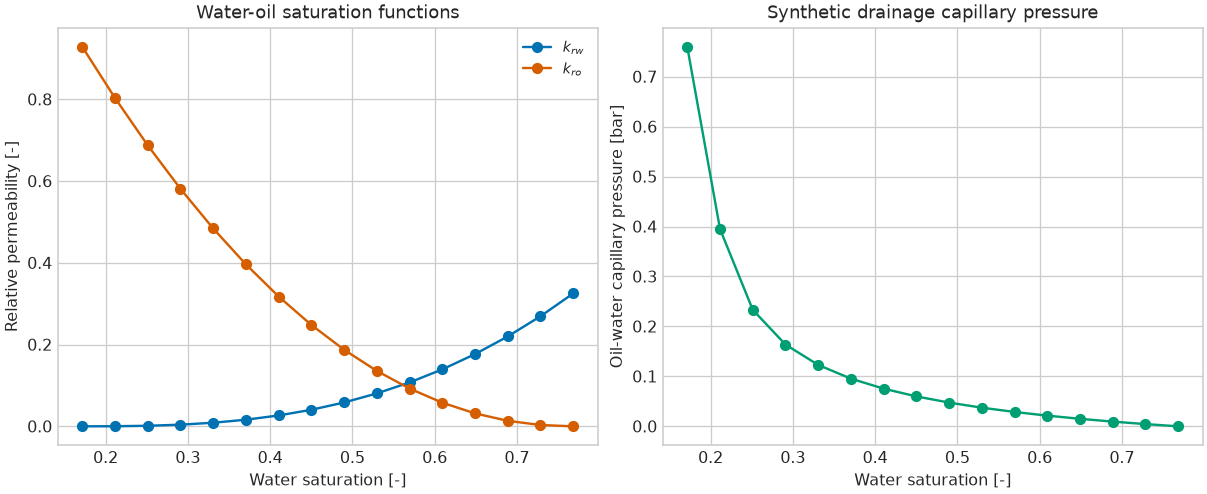

In [16]:
scal_figure, scal_axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.3),
    constrained_layout=True,
)
scal_axes[0].plot(
    swof_table["Sw"],
    swof_table["krw"],
    marker="o",
    label="$k_{rw}$",
    color="#0072B2",
)
scal_axes[0].plot(
    swof_table["Sw"],
    swof_table["kro"],
    marker="o",
    label="$k_{ro}$",
    color="#D55E00",
)
scal_axes[0].set_xlabel("Water saturation [-]")
scal_axes[0].set_ylabel("Relative permeability [-]")
scal_axes[0].set_title("Water-oil saturation functions")
scal_axes[0].legend()

scal_axes[1].plot(
    swof_table["Sw"],
    swof_table["Pcow_bar"],
    marker="o",
    color="#009E73",
)
scal_axes[1].set_xlabel("Water saturation [-]")
scal_axes[1].set_ylabel("Oil-water capillary pressure [bar]")
scal_axes[1].set_title("Synthetic drainage capillary pressure")

scal_plot_path = OUTPUT_DIRECTORY / "scal_saturation_functions.png"
scal_figure.savefig(scal_plot_path, dpi=170)
plt.show()

## 7. Fluid samples and NeqSim PVT

A representative reservoir-fluid study normally reconciles a downhole sample with separator oil
and gas, checks contamination and compositional closure, and matches CCE, DLE, separator tests,
density and viscosity. Here a synthetic recombined sample is characterized with:

- SRK equation of state;
- classic mixing rule;
- volume correction;
- Pedersen heavy-end characterization; and
- 12 pseudo-components for the C20+ fraction.

NeqSim generates the thermodynamic path. The notebook then formats the results to Flow's strict
`PVTO`, `PVDG` and `PVTW` table contracts.

In [17]:
LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]

TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]

PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)

fluid_sample_rows = [
    {
        "fraction": component_name,
        "mole_percent": amount,
        "molar_mass_kg_mol": np.nan,
        "relative_density": np.nan,
        "type": "named component",
    }
    for component_name, amount in LIGHT_COMPONENTS
]
fluid_sample_rows.extend(
    {
        "fraction": cut_name,
        "mole_percent": amount,
        "molar_mass_kg_mol": molar_mass,
        "relative_density": relative_density,
        "type": "TBP cut",
    }
    for cut_name, amount, molar_mass, relative_density in TBP_CUTS
)
fluid_sample_rows.append(
    {
        "fraction": PLUS_FRACTION[0] + "+",
        "mole_percent": PLUS_FRACTION[1],
        "molar_mass_kg_mol": PLUS_FRACTION[2],
        "relative_density": PLUS_FRACTION[3],
        "type": "plus fraction",
    }
)
fluid_sample = pd.DataFrame(fluid_sample_rows)
fluid_sample_closure_percent = fluid_sample["mole_percent"].sum()
display(fluid_sample)
print(f"Fluid-sample closure: {fluid_sample_closure_percent:.8f} mol%")

,fraction,mole_percent,molar_mass_kg_mol,relative_density,type
0,nitrogen,0.39,NaN,NaN,named component
1,CO2,0.30,NaN,NaN,named component
2,methane,40.20,NaN,NaN,named component
3,ethane,7.61,NaN,NaN,named component
4,propane,7.95,NaN,NaN,named component
5,i-butane,1.19,NaN,NaN,named component
6,n-butane,4.08,NaN,NaN,named component
7,i-pentane,1.39,NaN,NaN,named component
8,n-pentane,2.15,NaN,NaN,named component
9,n-hexane,2.79,NaN,NaN,named component


Fluid-sample closure: 100.00000000 mol%


In [18]:
def build_reservoir_fluid():
    fluid_model = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        INITIAL_PRESSURE_BARA,
    )
    for component_name, amount_mol_percent in LIGHT_COMPONENTS:
        fluid_model.addComponent(component_name, amount_mol_percent)
    for cut_name, amount, molar_mass, relative_density in TBP_CUTS:
        fluid_model.addTBPfraction(
            cut_name,
            amount,
            molar_mass,
            relative_density,
        )
    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    fluid_model.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )
    characterization = fluid_model.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()
    fluid_model.setMixingRule("classic")
    fluid_model.useVolumeCorrection(True)
    fluid_model.init(0)
    fluid_model.init(1)
    return fluid_model


reservoir_fluid = build_reservoir_fluid()
initial_fluid_state = reservoir_fluid.clone()
TPflash(initial_fluid_state)
initial_fluid_state.initPhysicalProperties()

DLE_PRESSURES_BARA = np.array(
    [320.0, 280.0, 240.0, 210.0, 180.0, 150.0, 100.0, 50.0, 1.01325]
)
GAS_PVT_PRESSURES_BARA = np.array(
    [
        1.01325,
        25.0,
        50.0,
        75.0,
        100.0,
        125.0,
        150.0,
        175.0,
        200.0,
        225.0,
        250.0,
        275.0,
        300.0,
        325.0,
    ]
)

DifferentialLiberation = (
    jneqsim.pvtsimulation.simulation.DifferentialLiberation
)
dle = DifferentialLiberation(reservoir_fluid.clone())
dle.setPressures(DLE_PRESSURES_BARA.tolist())
dle.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
dle.runCalc()

bubble_pressure_bara = float(dle.getSaturationPressure())
dle_rs = np.asarray(dle.getRs(), dtype=float)
dle_bo = np.asarray(dle.getBo(), dtype=float)
dle_bg = np.asarray(dle.getBg(), dtype=float)
dle_oil_density_kg_m3 = np.asarray(dle.getOilDensity(), dtype=float)

saturation_gas_state = reservoir_fluid.clone()
saturation_gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_gas_state.setPressure(bubble_pressure_bara * 0.99, "bara")
TPflash(saturation_gas_state)
saturation_gas_state.initPhysicalProperties()
saturation_gas_viscosity_cp = saturation_gas_state.getPhase(
    "gas"
).getViscosity("cP")

black_oil_rows = []
for pressure_bara, rs_value, bo_value, bg_value, oil_density in zip(
    DLE_PRESSURES_BARA,
    dle_rs,
    dle_bo,
    dle_bg,
    dle_oil_density_kg_m3,
):
    property_state = reservoir_fluid.clone()
    property_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    property_state.setPressure(float(pressure_bara), "bara")
    TPflash(property_state)
    property_state.initPhysicalProperties()
    oil_viscosity_cp = property_state.getPhase("oil").getViscosity("cP")
    if property_state.hasPhaseType("gas"):
        gas_viscosity_cp = property_state.getPhase("gas").getViscosity("cP")
    else:
        gas_viscosity_cp = saturation_gas_viscosity_cp
    black_oil_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Rs_Sm3_Sm3": float(rs_value),
            "Bo_rm3_Sm3": float(bo_value),
            "oil_density_kg_m3": float(oil_density),
            "oil_viscosity_cP": float(oil_viscosity_cp),
            "DLE_Bg_rm3_Sm3": float(bg_value),
            "gas_viscosity_cP": float(gas_viscosity_cp),
        }
    )

black_oil_source_table = pd.DataFrame(black_oil_rows)
display(black_oil_source_table)
print(f"DLE bubble pressure: {bubble_pressure_bara:.6f} bara")

,pressure_bara,Rs_Sm3_Sm3,Bo_rm3_Sm3,oil_density_kg_m3,oil_viscosity_cP,DLE_Bg_rm3_Sm3,gas_viscosity_cP
0,320.00000,221.463335,1.735820,674.441072,0.261129,0.000000,0.021115
1,280.00000,221.463335,1.753925,667.479120,0.249351,0.000000,0.021115
2,240.00000,221.463335,1.774401,659.776613,0.237012,0.000000,0.021115
3,210.00000,221.463335,1.791664,653.419443,0.227338,0.000000,0.021115
4,180.00000,207.542314,1.763764,656.127634,0.232828,0.006242,0.020371
5,150.00000,175.220405,1.673200,673.396580,0.265961,0.007493,0.018413
6,100.00000,127.844017,1.540088,702.818336,0.340503,0.011436,0.015916
7,50.00000,85.274667,1.416403,734.292391,0.467895,0.023697,0.014067
8,1.01325,0.000000,1.049413,810.651241,1.988251,1.263281,0.011534


DLE bubble pressure: 191.829020 bara


In [19]:
stock_tank_state = reservoir_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initPhysicalProperties()

stock_oil_density_kg_m3 = stock_tank_state.getPhase("oil").getDensity(
    "kg/m3"
)
stock_gas_density_kg_m3 = stock_tank_state.getPhase("gas").getDensity(
    "kg/m3"
)

bubble_bo = float(
    np.interp(
        bubble_pressure_bara,
        np.sort(DLE_PRESSURES_BARA),
        dle_bo[np.argsort(DLE_PRESSURES_BARA)],
    )
)
bubble_state = reservoir_fluid.clone()
bubble_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
bubble_state.setPressure(bubble_pressure_bara, "bara")
TPflash(bubble_state)
bubble_state.initPhysicalProperties()
bubble_oil_viscosity_cp = bubble_state.getPhase("oil").getViscosity("cP")
maximum_solution_gor = float(np.max(dle_rs))

saturated_oil_rows = []
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    if row["pressure_bara"] >= bubble_pressure_bara:
        continue
    if (
        saturated_oil_rows
        and row["Rs_Sm3_Sm3"] <= saturated_oil_rows[-1]["Rs"]
    ):
        continue
    saturated_oil_rows.append(
        {
            "Rs": max(row["Rs_Sm3_Sm3"], 1.0e-6),
            "pressure": row["pressure_bara"],
            "Bo": row["Bo_rm3_Sm3"],
            "mu_o": row["oil_viscosity_cP"],
        }
    )

saturated_oil_rows.append(
    {
        "Rs": maximum_solution_gor,
        "pressure": bubble_pressure_bara,
        "Bo": bubble_bo,
        "mu_o": bubble_oil_viscosity_cp,
    }
)

maximum_pressure_row = black_oil_source_table.loc[
    black_oil_source_table["pressure_bara"].idxmax()
]
undersaturated_oil_row = {
    "pressure": float(maximum_pressure_row["pressure_bara"]),
    "Bo": float(maximum_pressure_row["Bo_rm3_Sm3"]),
    "mu_o": float(maximum_pressure_row["oil_viscosity_cP"]),
}

stock_gas_template = stock_tank_state.phaseToSystem("gas")
dry_gas_rows = []
for pressure_bara in GAS_PVT_PRESSURES_BARA:
    gas_state = stock_gas_template.clone()
    gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    gas_state.setPressure(float(pressure_bara), "bara")
    TPflash(gas_state)
    gas_state.initPhysicalProperties()
    gas_density_kg_m3 = gas_state.getPhase("gas").getDensity("kg/m3")
    dry_gas_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Bg_rm3_Sm3": stock_gas_density_kg_m3 / gas_density_kg_m3,
            "gas_viscosity_cP": (
                gas_state.getPhase("gas").getViscosity("cP")
            ),
        }
    )
dry_gas_table = pd.DataFrame(dry_gas_rows)


def build_water_state(temperature_c, pressure_bara):
    water_state = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    water_state.addComponent("water", 1.0)
    water_state.setMixingRule(10)
    TPflash(water_state)
    water_state.initPhysicalProperties()
    return water_state


standard_water_state = build_water_state(
    STANDARD_TEMPERATURE_C,
    STANDARD_PRESSURE_BARA,
)
reference_water_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara,
)
water_low_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara - 1.0,
)
water_high_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara + 1.0,
)

stock_water_density_kg_m3 = standard_water_state.getPhase(
    "aqueous"
).getDensity("kg/m3")
reservoir_water_density_kg_m3 = reference_water_state.getPhase(
    "aqueous"
).getDensity("kg/m3")
water_fvf = stock_water_density_kg_m3 / reservoir_water_density_kg_m3
water_compressibility_per_bar = (
    water_high_pressure_state.getPhase("aqueous").getDensity("kg/m3")
    - water_low_pressure_state.getPhase("aqueous").getDensity("kg/m3")
) / (2.0 * reservoir_water_density_kg_m3)
water_viscosity_cp = reference_water_state.getPhase(
    "aqueous"
).getViscosity("cP")

pvt_audit = pd.DataFrame(
    {
        "quantity": [
            "bubble pressure",
            "stock oil density",
            "stock gas density",
            "stock water density",
            "water FVF",
            "water compressibility",
            "water viscosity",
        ],
        "value": [
            bubble_pressure_bara,
            stock_oil_density_kg_m3,
            stock_gas_density_kg_m3,
            stock_water_density_kg_m3,
            water_fvf,
            water_compressibility_per_bar,
            water_viscosity_cp,
        ],
        "unit": [
            "bara",
            "kg/m³",
            "kg/m³",
            "kg/m³",
            "rm³/Sm³",
            "1/bar",
            "cP",
        ],
    }
)
display(pvt_audit)

,quantity,value,unit
0,bubble pressure,191.829020,bara
1,stock oil density,832.469873,kg/m³
2,stock gas density,1.123756,kg/m³
3,stock water density,997.784768,kg/m³
4,water FVF,1.018649,rm³/Sm³
5,water compressibility,0.000049,1/bar
6,water viscosity,0.304081,cP


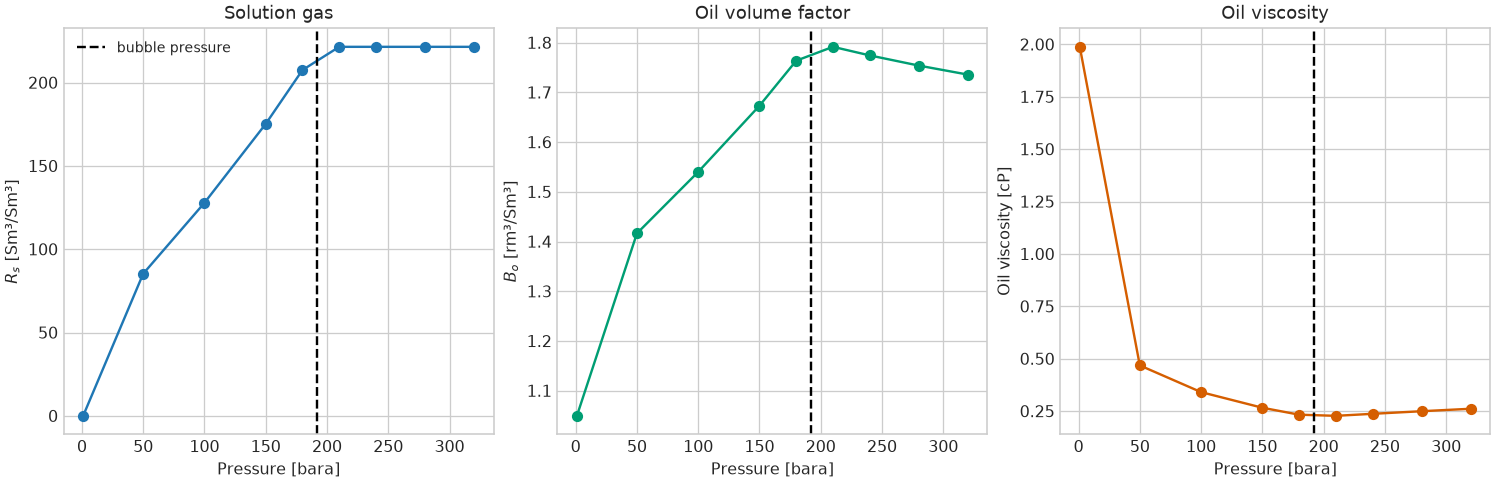

In [20]:
pvt_figure, pvt_axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 4.2),
    constrained_layout=True,
)
pvt_axes[0].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Rs_Sm3_Sm3"],
    marker="o",
)
pvt_axes[0].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="bubble pressure",
)
pvt_axes[0].set_xlabel("Pressure [bara]")
pvt_axes[0].set_ylabel("$R_s$ [Sm³/Sm³]")
pvt_axes[0].set_title("Solution gas")
pvt_axes[0].legend()

pvt_axes[1].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Bo_rm3_Sm3"],
    marker="o",
    color="#009E73",
)
pvt_axes[1].axvline(bubble_pressure_bara, color="black", linestyle="--")
pvt_axes[1].set_xlabel("Pressure [bara]")
pvt_axes[1].set_ylabel("$B_o$ [rm³/Sm³]")
pvt_axes[1].set_title("Oil volume factor")

pvt_axes[2].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["oil_viscosity_cP"],
    marker="o",
    color="#D55E00",
)
pvt_axes[2].axvline(bubble_pressure_bara, color="black", linestyle="--")
pvt_axes[2].set_xlabel("Pressure [bara]")
pvt_axes[2].set_ylabel("Oil viscosity [cP]")
pvt_axes[2].set_title("Oil viscosity")

pvt_plot_path = OUTPUT_DIRECTORY / "neqsim_fluid_sample_pvt.png"
pvt_figure.savefig(pvt_plot_path, dpi=170)
plt.show()

## 8. From conditioned wells to a fine geological model

The well summaries are sparse. Seismic attributes provide spatial trends, while geostatistics adds
correlated variability and makes uncertainty explicit.

This example uses:

1. ordinary kriging of well-average porosity;
2. a seismic-derived sand-probability trend;
3. anisotropic exponential random fields; and
4. layer-dependent vertical trends.

The realization is one plausible model, not a unique interpretation. A production study should
carry multiple structural, facies, property, contact and SCAL/PVT realizations.

In [21]:
fine_nx = 40
fine_ny = 32
fine_nz = 8
fine_dx_m = 50.0
fine_dy_m = 50.0

fine_x_m = (np.arange(fine_nx) + 0.5) * fine_dx_m
fine_y_m = (np.arange(fine_ny) + 0.5) * fine_dy_m
fine_x_grid_m, fine_y_grid_m = np.meshgrid(fine_x_m, fine_y_m)

well_conditioning = well_locations.merge(
    petrophysical_summary,
    on="well",
)
porosity_condition_values = well_conditioning[
    "mean_PHIE_fraction"
].fillna(petrophysical_summary["mean_PHIE_fraction"].median())

porosity_variogram = gs.Exponential(
    dim=2,
    var=0.0025,
    len_scale=[650.0, 280.0],
    angles=0.35,
)
porosity_kriging = gs.krige.Ordinary(
    porosity_variogram,
    cond_pos=(
        well_conditioning["x_m"].to_numpy(),
        well_conditioning["y_m"].to_numpy(),
    ),
    cond_val=porosity_condition_values.to_numpy(),
)
kriged_porosity_flat, kriging_variance_flat = porosity_kriging(
    (
        fine_x_grid_m.ravel(),
        fine_y_grid_m.ravel(),
    )
)
kriged_porosity_map = kriged_porosity_flat.reshape(fine_ny, fine_nx)
kriging_standard_deviation_map = np.sqrt(
    kriging_variance_flat.reshape(fine_ny, fine_nx)
)

seismic_attribute = gaussian_filter(
    channel_factor + 0.20 * random_generator.normal(size=channel_factor.shape),
    sigma=1.2,
)
seismic_attribute = (
    seismic_attribute - seismic_attribute.min()
) / (seismic_attribute.max() - seismic_attribute.min())
sand_probability_map = np.clip(
    0.22 + 0.66 * seismic_attribute,
    0.10,
    0.93,
)

property_random_field = gs.SRF(
    porosity_variogram,
    mean=0.0,
    seed=RANDOM_SEED + 1,
)
property_residual_map = property_random_field(
    (
        fine_x_grid_m.ravel(),
        fine_y_grid_m.ravel(),
    )
).reshape(fine_ny, fine_nx)
property_residual_map /= np.std(property_residual_map)

fine_top_depth_m = interpreted_top_depth_m.copy()
fine_total_thickness_m = interpreted_thickness_m.copy()
fine_layer_thickness_m = fine_total_thickness_m / fine_nz

fine_porosity = np.empty((fine_nz, fine_ny, fine_nx))
fine_ntg = np.empty_like(fine_porosity)
fine_permx_mD = np.empty_like(fine_porosity)
fine_permy_mD = np.empty_like(fine_porosity)
fine_permz_mD = np.empty_like(fine_porosity)
fine_facies = np.empty_like(fine_porosity, dtype=int)

for layer_index in range(fine_nz):
    layer_random = gs.SRF(
        porosity_variogram,
        mean=0.0,
        seed=RANDOM_SEED + 10 + layer_index,
    )
    layer_field = layer_random(
        (
            fine_x_grid_m.ravel(),
            fine_y_grid_m.ravel(),
        )
    ).reshape(fine_ny, fine_nx)
    layer_field /= np.std(layer_field)
    layer_probability = np.clip(
        sand_probability_map
        + 0.06 * layer_field
        - 0.025 * abs(layer_index - 3.5),
        0.05,
        0.97,
    )
    layer_uniform = random_generator.uniform(size=(fine_ny, fine_nx))
    layer_facies = layer_uniform < layer_probability
    layer_porosity = (
        kriged_porosity_map
        + 0.018 * property_residual_map
        + 0.010 * layer_field
        - 0.006 * abs(layer_index - 3.5)
    )
    layer_porosity = np.where(
        layer_facies,
        np.clip(layer_porosity, 0.10, 0.33),
        np.clip(0.07 + 0.02 * layer_field, 0.03, 0.12),
    )
    layer_ntg = np.where(layer_facies, 1.0, 0.08)
    layer_permx = np.clip(
        10.0
        ** (
            core_intercept
            + core_slope * layer_porosity
        ),
        0.05,
        5000.0,
    )
    layer_permx = np.where(layer_facies, layer_permx, 0.08)

    fine_facies[layer_index] = layer_facies.astype(int)
    fine_porosity[layer_index] = layer_porosity
    fine_ntg[layer_index] = layer_ntg
    fine_permx_mD[layer_index] = layer_permx
    fine_permy_mD[layer_index] = 0.75 * layer_permx
    fine_permz_mD[layer_index] = 0.08 * layer_permx

fine_model_summary = pd.DataFrame(
    {
        "property": [
            "cells",
            "sand fraction",
            "porosity mean",
            "porosity P10",
            "porosity P90",
            "permeability geometric mean",
            "top-depth range",
            "gross-thickness mean",
        ],
        "value": [
            fine_nx * fine_ny * fine_nz,
            fine_facies.mean(),
            np.average(fine_porosity, weights=fine_ntg),
            np.quantile(fine_porosity[fine_facies == 1], 0.10),
            np.quantile(fine_porosity[fine_facies == 1], 0.90),
            np.exp(np.mean(np.log(fine_permx_mD[fine_facies == 1]))),
            fine_top_depth_m.max() - fine_top_depth_m.min(),
            fine_total_thickness_m.mean(),
        ],
        "unit": [
            "count",
            "fraction",
            "fraction",
            "fraction",
            "fraction",
            "mD",
            "m",
            "m",
        ],
    }
)
display(well_conditioning)
display(fine_model_summary)

,well,x_m,y_m,gross_m,net_pay_m,NTG_fraction,mean_PHIE_fraction,geometric_mean_perm_mD,mean_SW_fraction
0,BH-01,330.0,360.0,24.0,11.0,0.458333,0.238267,375.425271,0.182694
1,BH-02,690.0,1180.0,29.0,15.0,0.517241,0.236629,349.970626,0.182978
2,BH-03,980.0,720.0,33.5,23.0,0.686567,0.236988,355.395138,0.188849
3,BH-04,1450.0,340.0,24.5,11.5,0.469388,0.239242,391.433069,0.182539
4,BH-05,1690.0,1240.0,24.0,7.0,0.291667,0.234908,325.105150,0.238829


,property,value,unit
0,cells,10240.000000,count
1,sand fraction,0.370215,fraction
2,porosity mean,0.186456,fraction
3,porosity P10,0.171191,fraction
4,porosity P90,0.231680,fraction
5,permeability geometric mean,81.515882,mD
6,top-depth range,75.977654,m
7,gross-thickness mean,28.145915,m


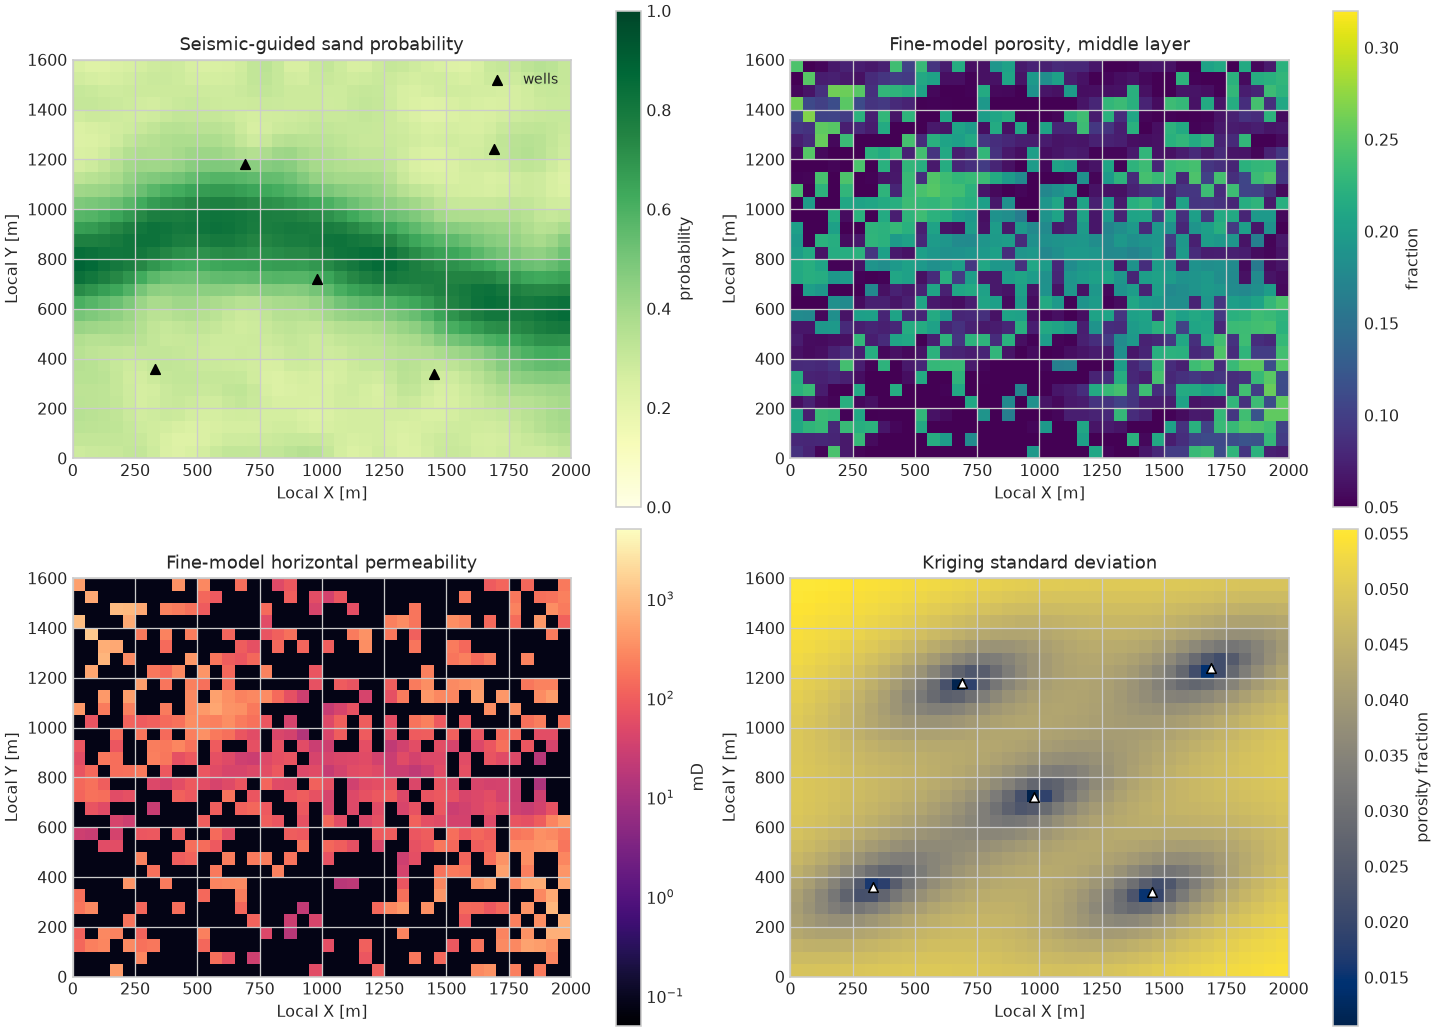

In [22]:
middle_layer_index = fine_nz // 2

geomodel_figure, geomodel_axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 9.0),
    constrained_layout=True,
)

sand_image = geomodel_axes[0, 0].imshow(
    sand_probability_map,
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="YlGn",
    vmin=0.0,
    vmax=1.0,
)
geomodel_axes[0, 0].scatter(
    well_locations["x_m"],
    well_locations["y_m"],
    marker="^",
    color="black",
    label="wells",
)
geomodel_axes[0, 0].set_xlabel("Local X [m]")
geomodel_axes[0, 0].set_ylabel("Local Y [m]")
geomodel_axes[0, 0].set_title("Seismic-guided sand probability")
geomodel_axes[0, 0].legend()
geomodel_figure.colorbar(
    sand_image,
    ax=geomodel_axes[0, 0],
    label="probability",
)

porosity_image = geomodel_axes[0, 1].imshow(
    fine_porosity[middle_layer_index],
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="viridis",
    vmin=0.05,
    vmax=0.32,
)
geomodel_axes[0, 1].set_xlabel("Local X [m]")
geomodel_axes[0, 1].set_ylabel("Local Y [m]")
geomodel_axes[0, 1].set_title("Fine-model porosity, middle layer")
geomodel_figure.colorbar(
    porosity_image,
    ax=geomodel_axes[0, 1],
    label="fraction",
)

permeability_image = geomodel_axes[1, 0].imshow(
    fine_permx_mD[middle_layer_index],
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="magma",
    norm=LogNorm(vmin=0.05, vmax=5000.0),
)
geomodel_axes[1, 0].set_xlabel("Local X [m]")
geomodel_axes[1, 0].set_ylabel("Local Y [m]")
geomodel_axes[1, 0].set_title("Fine-model horizontal permeability")
geomodel_figure.colorbar(
    permeability_image,
    ax=geomodel_axes[1, 0],
    label="mD",
)

uncertainty_image = geomodel_axes[1, 1].imshow(
    kriging_standard_deviation_map,
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="cividis",
)
geomodel_axes[1, 1].scatter(
    well_locations["x_m"],
    well_locations["y_m"],
    marker="^",
    color="white",
    edgecolor="black",
)
geomodel_axes[1, 1].set_xlabel("Local X [m]")
geomodel_axes[1, 1].set_ylabel("Local Y [m]")
geomodel_axes[1, 1].set_title("Kriging standard deviation")
geomodel_figure.colorbar(
    uncertainty_image,
    ax=geomodel_axes[1, 1],
    label="porosity fraction",
)

geomodel_plot_path = OUTPUT_DIRECTORY / "fine_geological_model.png"
geomodel_figure.savefig(geomodel_plot_path, dpi=170)
plt.show()

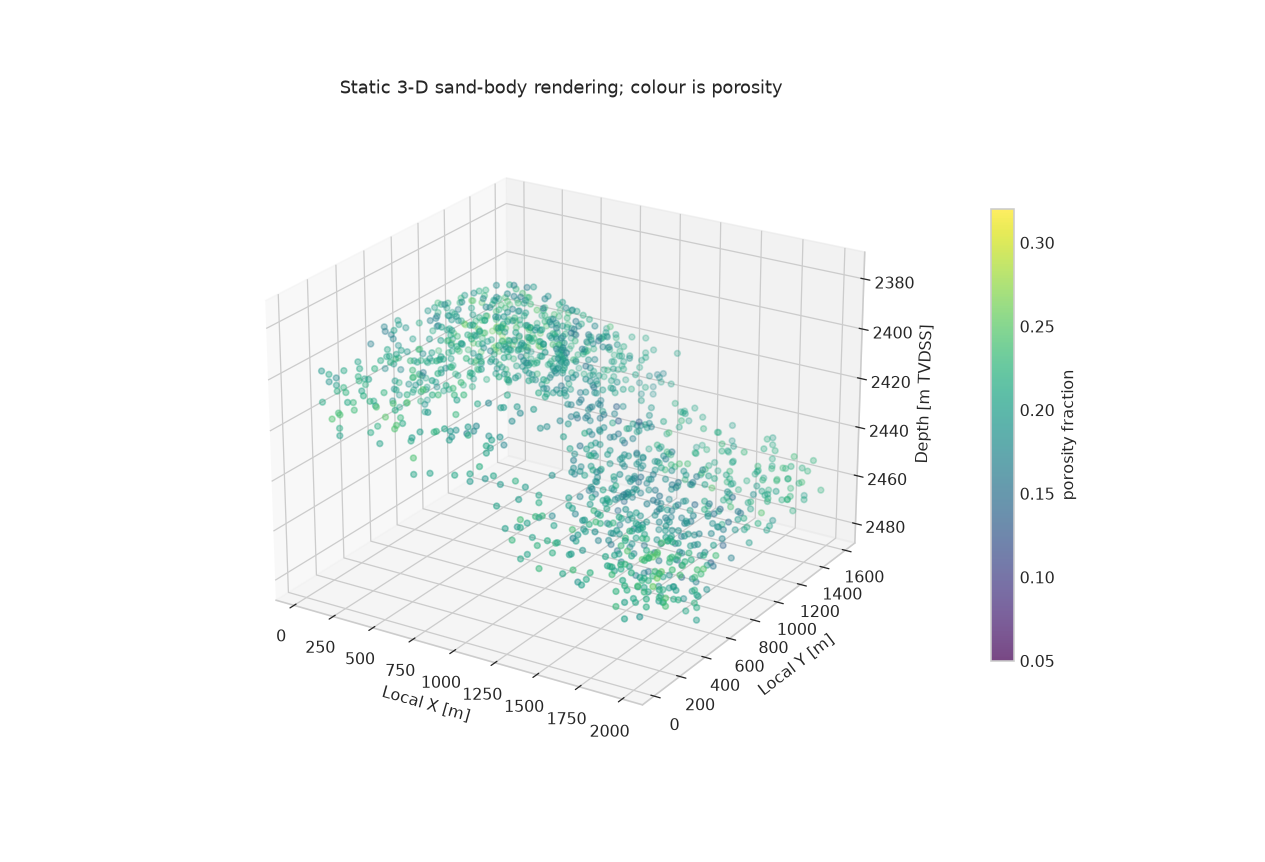

In [23]:
layer_indices, y_indices, x_indices = np.where(fine_facies == 1)
sample_indices = np.arange(0, len(layer_indices), 3)
sample_layer = layer_indices[sample_indices]
sample_y = y_indices[sample_indices]
sample_x = x_indices[sample_indices]
sample_porosity = fine_porosity[
    sample_layer,
    sample_y,
    sample_x,
]
sample_depth_m = (
    fine_top_depth_m[sample_y, sample_x]
    + (sample_layer + 0.5)
    * fine_layer_thickness_m[sample_y, sample_x]
)

static_3d_figure = plt.figure(figsize=(11.0, 7.5))
static_3d_axis = static_3d_figure.add_subplot(111, projection="3d")
static_3d_scatter = static_3d_axis.scatter(
    fine_x_m[sample_x],
    fine_y_m[sample_y],
    sample_depth_m,
    c=sample_porosity,
    cmap="viridis",
    vmin=0.05,
    vmax=0.32,
    s=13,
    alpha=0.72,
)
static_3d_axis.set_xlabel("Local X [m]")
static_3d_axis.set_ylabel("Local Y [m]")
static_3d_axis.set_zlabel("Depth [m TVDSS]")
static_3d_axis.set_title(
    "Static 3-D sand-body rendering; colour is porosity"
)
static_3d_axis.invert_zaxis()
static_3d_axis.view_init(elev=23.0, azim=-58.0)
static_3d_figure.colorbar(
    static_3d_scatter,
    ax=static_3d_axis,
    label="porosity fraction",
    shrink=0.68,
    pad=0.10,
)
static_3d_path = OUTPUT_DIRECTORY / "fine_geomodel_3d.png"
static_3d_figure.savefig(static_3d_path, dpi=170, bbox_inches="tight")
plt.show()

## 9. Flow-model upscaling

The fine model resolves geological variability; Flow needs a smaller grid for repeated forecasts.
Porosity and NTG are upscaled together so that pore volume is conserved:

$$
\phi_c NTG_c V_c =
\sum_{f \in c} \phi_f NTG_f V_f.
$$

Horizontal permeability uses an NTG-weighted arithmetic average as a transparent parallel-flow
proxy. Vertical permeability uses a harmonic average to make thin vertical barriers influential.
These are screening choices. A mature model should use pressure-solver or transmissibility-based
upscaling and verify rate/pressure equivalence on representative flow experiments.

In [24]:
coarse_nx = fine_nx // 2
coarse_ny = fine_ny // 2
coarse_nz = fine_nz // 2
coarse_dx_m = fine_dx_m * 2.0
coarse_dy_m = fine_dy_m * 2.0

coarse_top_depth_m = fine_top_depth_m.reshape(
    coarse_ny,
    2,
    coarse_nx,
    2,
).mean(axis=(1, 3))
coarse_total_thickness_m = fine_total_thickness_m.reshape(
    coarse_ny,
    2,
    coarse_nx,
    2,
).mean(axis=(1, 3))
coarse_dz_m = np.repeat(
    (coarse_total_thickness_m / coarse_nz)[None, :, :],
    coarse_nz,
    axis=0,
)

coarse_porosity = np.empty((coarse_nz, coarse_ny, coarse_nx))
coarse_ntg = np.empty_like(coarse_porosity)
coarse_permx_mD = np.empty_like(coarse_porosity)
coarse_permy_mD = np.empty_like(coarse_porosity)
coarse_permz_mD = np.empty_like(coarse_porosity)

fine_cell_volume_m3 = (
    fine_dx_m
    * fine_dy_m
    * np.repeat(
        fine_layer_thickness_m[None, :, :],
        fine_nz,
        axis=0,
    )
)

for coarse_k in range(coarse_nz):
    for coarse_j in range(coarse_ny):
        for coarse_i in range(coarse_nx):
            fine_slice = np.s_[
                2 * coarse_k : 2 * coarse_k + 2,
                2 * coarse_j : 2 * coarse_j + 2,
                2 * coarse_i : 2 * coarse_i + 2,
            ]
            block_ntg = fine_ntg[fine_slice]
            block_porosity = fine_porosity[fine_slice]
            block_permx = fine_permx_mD[fine_slice]
            block_permy = fine_permy_mD[fine_slice]
            block_permz = fine_permz_mD[fine_slice]
            block_volume = fine_cell_volume_m3[fine_slice]
            coarse_ntg_value = float(
                np.sum(block_ntg * block_volume)
                / np.sum(block_volume)
            )
            pore_weight = np.maximum(
                block_ntg * block_volume,
                1.0e-8,
            )
            coarse_ntg[coarse_k, coarse_j, coarse_i] = coarse_ntg_value
            coarse_porosity[coarse_k, coarse_j, coarse_i] = np.average(
                block_porosity,
                weights=pore_weight,
            )
            coarse_permx_mD[coarse_k, coarse_j, coarse_i] = np.average(
                block_permx,
                weights=pore_weight,
            )
            coarse_permy_mD[coarse_k, coarse_j, coarse_i] = np.average(
                block_permy,
                weights=pore_weight,
            )
            coarse_permz_mD[coarse_k, coarse_j, coarse_i] = (
                np.sum(pore_weight)
                / np.sum(
                    pore_weight
                    / np.maximum(block_permz, 1.0e-6)
                )
            )

coarse_cell_volume_m3 = coarse_dx_m * coarse_dy_m * coarse_dz_m
fine_pore_volume_m3 = np.sum(
    fine_cell_volume_m3 * fine_porosity * fine_ntg
)
coarse_pore_volume_m3 = np.sum(
    coarse_cell_volume_m3 * coarse_porosity * coarse_ntg
)
pore_volume_error_fraction = (
    coarse_pore_volume_m3 - fine_pore_volume_m3
) / fine_pore_volume_m3

average_initial_sw = float(
    petrophysical_summary["mean_SW_fraction"].median()
)
initial_oil_in_place_sm3 = (
    coarse_pore_volume_m3
    * (1.0 - average_initial_sw)
    / bubble_bo
)

upscaling_audit = pd.DataFrame(
    {
        "quantity": [
            "fine cells",
            "coarse cells",
            "fine pore volume",
            "coarse pore volume",
            "pore-volume error",
            "screening STOIIP",
            "coarse geometric mean kx",
            "coarse harmonic mean kz",
        ],
        "value": [
            fine_nx * fine_ny * fine_nz,
            coarse_nx * coarse_ny * coarse_nz,
            fine_pore_volume_m3,
            coarse_pore_volume_m3,
            pore_volume_error_fraction,
            initial_oil_in_place_sm3,
            np.exp(np.mean(np.log(coarse_permx_mD))),
            coarse_permz_mD.size / np.sum(1.0 / coarse_permz_mD),
        ],
        "unit": [
            "count",
            "count",
            "m³",
            "m³",
            "fraction",
            "Sm³",
            "mD",
            "mD",
        ],
    }
)
display(upscaling_audit)

,quantity,value,unit
0,fine cells,1.024000e+04,count
1,coarse cells,1.280000e+03,count
2,fine pore volume,7.657937e+06,m³
3,coarse pore volume,7.657937e+06,m³
4,pore-volume error,0.000000e+00,fraction
5,screening STOIIP,3.525368e+06,Sm³
6,coarse geometric mean kx,4.604482e+01,mD
7,coarse harmonic mean kz,2.880892e-02,mD


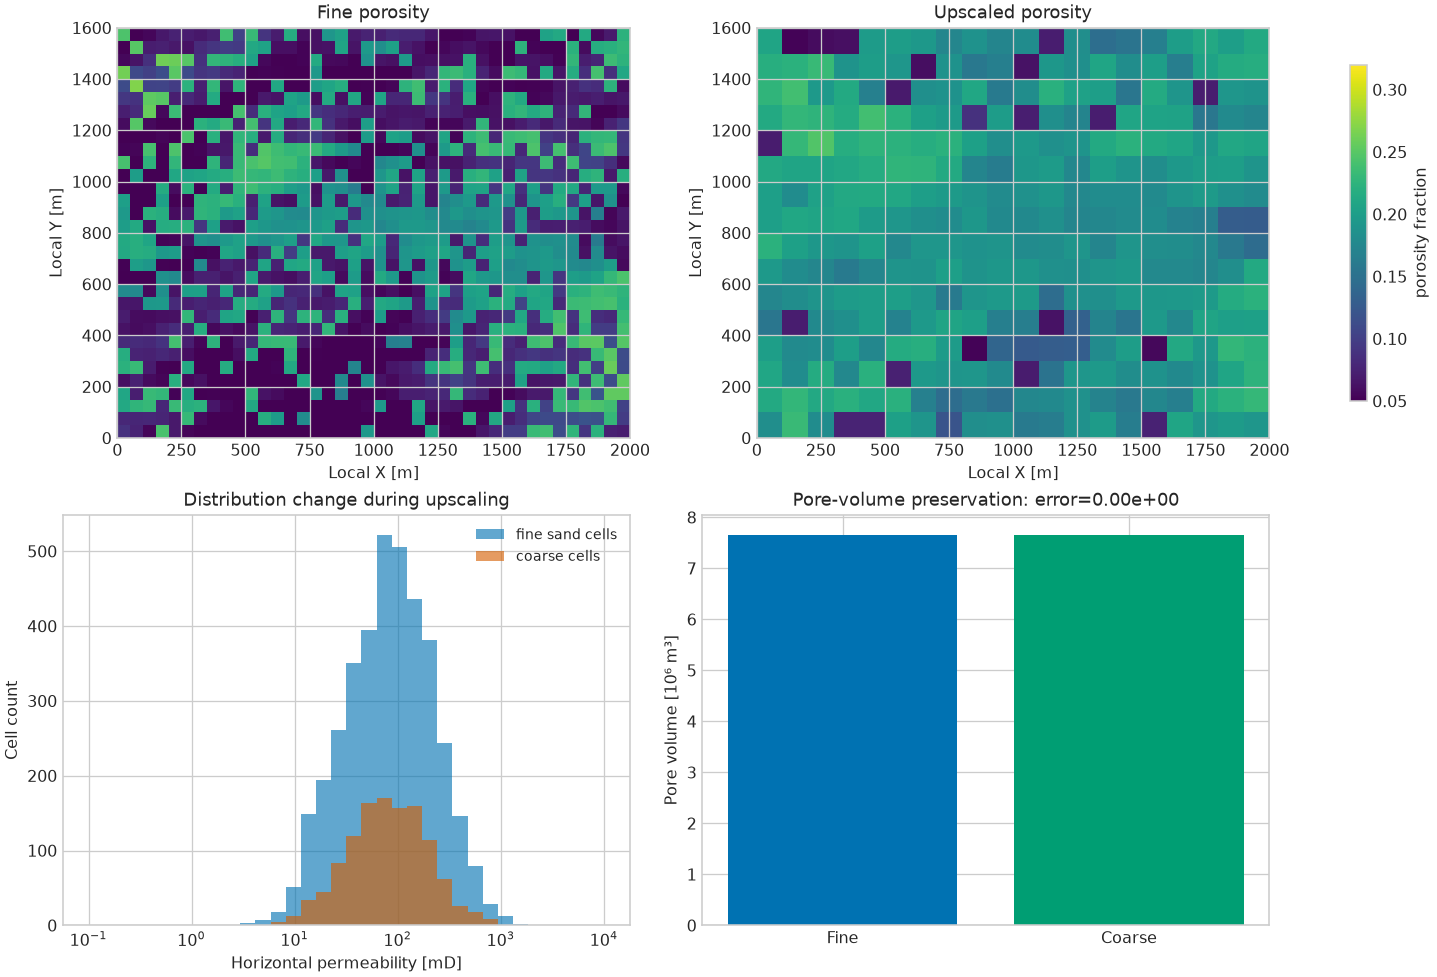

In [25]:
upscaling_figure, upscaling_axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 8.5),
    constrained_layout=True,
)

upscaling_axes[0, 0].imshow(
    fine_porosity[middle_layer_index],
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="viridis",
    vmin=0.05,
    vmax=0.32,
)
upscaling_axes[0, 0].set_title("Fine porosity")
upscaling_axes[0, 0].set_xlabel("Local X [m]")
upscaling_axes[0, 0].set_ylabel("Local Y [m]")

coarse_porosity_image = upscaling_axes[0, 1].imshow(
    coarse_porosity[coarse_nz // 2],
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="viridis",
    vmin=0.05,
    vmax=0.32,
)
upscaling_axes[0, 1].set_title("Upscaled porosity")
upscaling_axes[0, 1].set_xlabel("Local X [m]")
upscaling_axes[0, 1].set_ylabel("Local Y [m]")
upscaling_figure.colorbar(
    coarse_porosity_image,
    ax=upscaling_axes[:1, :],
    label="porosity fraction",
    shrink=0.82,
)

upscaling_axes[1, 0].hist(
    fine_permx_mD[fine_facies == 1],
    bins=np.logspace(-1, 4, 35),
    alpha=0.62,
    label="fine sand cells",
    color="#0072B2",
)
upscaling_axes[1, 0].hist(
    coarse_permx_mD.ravel(),
    bins=np.logspace(-1, 4, 35),
    alpha=0.62,
    label="coarse cells",
    color="#D55E00",
)
upscaling_axes[1, 0].set_xscale("log")
upscaling_axes[1, 0].set_xlabel("Horizontal permeability [mD]")
upscaling_axes[1, 0].set_ylabel("Cell count")
upscaling_axes[1, 0].set_title("Distribution change during upscaling")
upscaling_axes[1, 0].legend()

upscaling_axes[1, 1].bar(
    ["Fine", "Coarse"],
    [fine_pore_volume_m3 / 1.0e6, coarse_pore_volume_m3 / 1.0e6],
    color=["#0072B2", "#009E73"],
)
upscaling_axes[1, 1].set_ylabel("Pore volume [10⁶ m³]")
upscaling_axes[1, 1].set_title(
    f"Pore-volume preservation: error={pore_volume_error_fraction:.2e}"
)

upscaling_plot_path = OUTPUT_DIRECTORY / "flow_upscaling.png"
upscaling_figure.savefig(upscaling_plot_path, dpi=170)
plt.show()

## 10. Well placement from structure, quality and separation constraints

The example ranks cells by hydrocarbon pore thickness and permeability, then selects two producers
with a minimum inter-well distance. The injector is placed in a lower-quality downdip region and
completed through all layers. The producers are completed in the upper half of the model so the
forecast can demonstrate pressure support and later water movement without placing a producer
directly below the oil-water contact.

This is a transparent heuristic, not an optimal well-placement algorithm. A field study should
evaluate trajectories, drilling constraints, fault compartments, pressure support, sweep,
facilities, economics and uncertainty—typically with many Flow cases.

In [26]:
coarse_x_m = (np.arange(coarse_nx) + 0.5) * coarse_dx_m
coarse_y_m = (np.arange(coarse_ny) + 0.5) * coarse_dy_m
coarse_x_grid_m, coarse_y_grid_m = np.meshgrid(coarse_x_m, coarse_y_m)

hydrocarbon_pore_thickness_m = np.sum(
    coarse_dz_m
    * coarse_porosity
    * coarse_ntg
    * (1.0 - average_initial_sw),
    axis=0,
)
mean_log_permeability = np.mean(
    np.log10(np.maximum(coarse_permx_mD, 0.01)),
    axis=0,
)
structure_score = (
    coarse_top_depth_m.max() - coarse_top_depth_m
) / (
    coarse_top_depth_m.max() - coarse_top_depth_m.min()
)
quality_score = (
    hydrocarbon_pore_thickness_m
    / hydrocarbon_pore_thickness_m.max()
    + 0.30
    * (
        mean_log_permeability - mean_log_permeability.min()
    )
    / (
        mean_log_permeability.max() - mean_log_permeability.min()
    )
    + 0.25 * structure_score
)


def select_separated_cells(score_map, count, minimum_distance_cells):
    selected = []
    ranked_flat_indices = np.argsort(score_map.ravel())[::-1]
    for flat_index in ranked_flat_indices:
        j_index, i_index = np.unravel_index(flat_index, score_map.shape)
        if i_index in [0, score_map.shape[1] - 1]:
            continue
        if j_index in [0, score_map.shape[0] - 1]:
            continue
        if all(
            math.hypot(i_index - old_i, j_index - old_j)
            >= minimum_distance_cells
            for old_j, old_i in selected
        ):
            selected.append((j_index, i_index))
        if len(selected) == count:
            break
    return selected


producer_cells = select_separated_cells(
    quality_score,
    count=2,
    minimum_distance_cells=7.0,
)
distance_to_producers = np.full_like(quality_score, np.inf)
for producer_j, producer_i in producer_cells:
    cell_distance = np.hypot(
        coarse_x_grid_m
        - coarse_x_grid_m[producer_j, producer_i],
        coarse_y_grid_m
        - coarse_y_grid_m[producer_j, producer_i],
    )
    distance_to_producers = np.minimum(
        distance_to_producers,
        cell_distance,
    )

injector_candidate_score = (
    distance_to_producers / distance_to_producers.max()
    + 0.50
    * (
        coarse_top_depth_m - coarse_top_depth_m.min()
    )
    / (
        coarse_top_depth_m.max() - coarse_top_depth_m.min()
    )
    - 0.25 * quality_score / quality_score.max()
)
injector_candidate_score[[0, -1], :] = -np.inf
injector_candidate_score[:, [0, -1]] = -np.inf
injector_j, injector_i = np.unravel_index(
    np.argmax(injector_candidate_score),
    injector_candidate_score.shape,
)

well_plan = pd.DataFrame(
    [
        {
            "well": "PROD_A",
            "type": "producer",
            "i": producer_cells[0][1] + 1,
            "j": producer_cells[0][0] + 1,
            "x_m": coarse_x_grid_m[producer_cells[0]],
            "y_m": coarse_y_grid_m[producer_cells[0]],
        },
        {
            "well": "PROD_B",
            "type": "producer",
            "i": producer_cells[1][1] + 1,
            "j": producer_cells[1][0] + 1,
            "x_m": coarse_x_grid_m[producer_cells[1]],
            "y_m": coarse_y_grid_m[producer_cells[1]],
        },
        {
            "well": "WINJ",
            "type": "injector",
            "i": injector_i + 1,
            "j": injector_j + 1,
            "x_m": coarse_x_grid_m[injector_j, injector_i],
            "y_m": coarse_y_grid_m[injector_j, injector_i],
        },
    ]
)
display(well_plan)

,well,type,i,j,x_m,y_m
0,PROD_A,producer,4,9,350.0,850.0
1,PROD_B,producer,19,6,1850.0,550.0
2,WINJ,injector,14,15,1350.0,1450.0


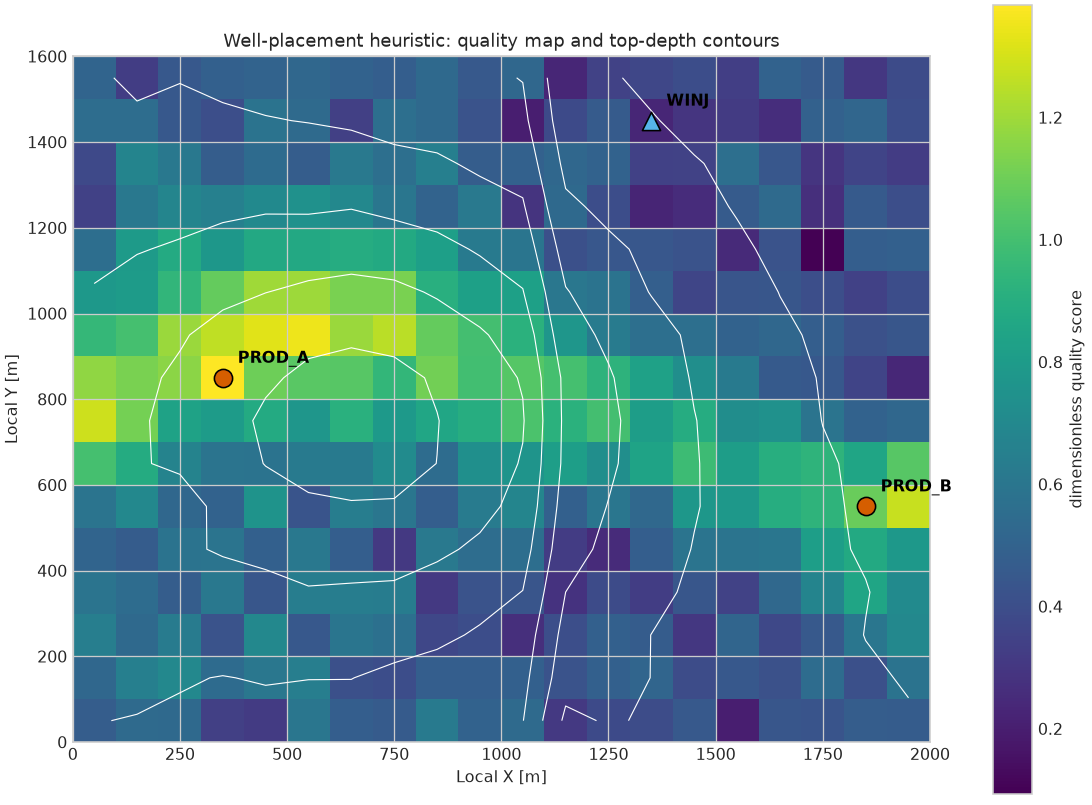

In [27]:
well_placement_figure, well_placement_axis = plt.subplots(
    figsize=(9.5, 7.0),
    constrained_layout=True,
)
quality_image = well_placement_axis.imshow(
    quality_score,
    origin="lower",
    extent=[0.0, 2000.0, 0.0, 1600.0],
    cmap="viridis",
)
well_placement_axis.contour(
    coarse_x_grid_m,
    coarse_y_grid_m,
    coarse_top_depth_m,
    colors="white",
    linewidths=0.7,
)
for plan_row in well_plan.itertuples():
    marker = "o" if plan_row.type == "producer" else "^"
    color = "#D55E00" if plan_row.type == "producer" else "#56B4E9"
    well_placement_axis.scatter(
        plan_row.x_m,
        plan_row.y_m,
        marker=marker,
        s=130,
        color=color,
        edgecolor="black",
        zorder=4,
    )
    well_placement_axis.text(
        plan_row.x_m + 35.0,
        plan_row.y_m + 35.0,
        plan_row.well,
        color="black",
        fontweight="bold",
    )
well_placement_axis.set_xlabel("Local X [m]")
well_placement_axis.set_ylabel("Local Y [m]")
well_placement_axis.set_title(
    "Well-placement heuristic: quality map and top-depth contours"
)
well_placement_figure.colorbar(
    quality_image,
    ax=well_placement_axis,
    label="dimensionless quality score",
)
well_placement_path = OUTPUT_DIRECTORY / "well_placement.png"
well_placement_figure.savefig(well_placement_path, dpi=170)
plt.show()

## 11. Generate every OPM Flow input

The next cells create:

- `NEQSIM_PVT.INC` from the synthetic fluid sample;
- `SWOF` from the synthetic SCAL samples;
- `SGOF` from an explicit gas-oil Corey screening model;
- `TOPS`, `DZ`, `PORO`, `NTG`, `PERMX`, `PERMY`, `PERMZ`, and `ACTNUM`;
- equilibrium contacts and initial solution gas;
- producer/injector completions and controls; and
- monthly report steps for eight years.

Three decks vary porosity, permeability and oil-water contact. The geological realization is held
fixed so the sensitivity can be interpreted. A full uncertainty workflow would also vary structure,
facies, SCAL, PVT and well placement.

In [28]:
pvto_lines = ["PVTO"]
for row_index, row in enumerate(saturated_oil_rows):
    is_last_saturated_row = row_index == len(saturated_oil_rows) - 1
    row_suffix = "" if is_last_saturated_row else " /"
    pvto_lines.append(
        "  "
        f"{row['Rs']:.8f} "
        f"{row['pressure']:.8f} "
        f"{row['Bo']:.8f} "
        f"{row['mu_o']:.8f}"
        f"{row_suffix}"
    )
    if is_last_saturated_row:
        pvto_lines.append(
            "    "
            f"{undersaturated_oil_row['pressure']:.8f} "
            f"{undersaturated_oil_row['Bo']:.8f} "
            f"{undersaturated_oil_row['mu_o']:.8f} /"
        )
pvto_lines.append("/")

pvdg_lines = ["PVDG"]
for row_index, row in dry_gas_table.iterrows():
    row_suffix = " /" if row_index == len(dry_gas_table) - 1 else ""
    pvdg_lines.append(
        "  "
        f"{row['pressure_bara']:.8f} "
        f"{row['Bg_rm3_Sm3']:.10f} "
        f"{row['gas_viscosity_cP']:.8f}"
        f"{row_suffix}"
    )

black_oil_include = "\n".join(
    [
        "-- Flow-compatible black-oil tables calculated with NeqSim",
        "-- Synthetic public teaching fluid; METRIC unit system.",
        "DENSITY",
        "  "
        f"{stock_oil_density_kg_m3:.8f} "
        f"{stock_water_density_kg_m3:.8f} "
        f"{stock_gas_density_kg_m3:.8f} /",
        "",
        *pvto_lines,
        "",
        *pvdg_lines,
        "",
        "PVTW",
        "  "
        f"{bubble_pressure_bara:.8f} "
        f"{water_fvf:.8f} "
        f"{water_compressibility_per_bar:.10e} "
        f"{water_viscosity_cp:.8f} "
        "0.0 /",
        "",
    ]
)

oil_table_audit = pd.DataFrame(saturated_oil_rows)
print("\n".join(black_oil_include.splitlines()[:45]))
display(oil_table_audit)

,Rs,pressure,Bo,mu_o
0,0.000001,1.01325,1.049413,1.988251
1,85.274667,50.00000,1.416403,0.467895
2,127.844017,100.00000,1.540088,0.340503
3,175.220405,150.00000,1.673200,0.265961
4,207.542314,180.00000,1.763764,0.232828
5,221.463335,191.82902,1.774765,0.221349


-- Flow-compatible black-oil tables calculated with NeqSim
-- Synthetic public teaching fluid; METRIC unit system.
DENSITY
  832.46987287 997.78476781 1.12375584 /

PVTO
  0.00000100 1.01325000 1.04941302 1.98825062 /
  85.27466748 50.00000000 1.41640306 0.46789457 /
  127.84401661 100.00000000 1.54008844 0.34050279 /
  175.22040514 150.00000000 1.67319953 0.26596147 /
  207.54231412 180.00000000 1.76376375 0.23282800 /
  221.46333462 191.82901955 1.77476478 0.22134927
    320.00000000 1.73581955 0.26112924 /
/

PVDG
  1.01325000 1.2818589582 0.01246940
  25.00000000 0.0488441363 0.01307352
  50.00000000 0.0228998684 0.01396134
  75.00000000 0.0143851836 0.01518012
  100.00000000 0.0102923856 0.01678759
  125.00000000 0.0080081872 0.01876950
  150.00000000 0.0066298529 0.02100938
  175.00000000 0.0057462306 0.02335460
  200.00000000 0.0051462842 0.02569432
  225.00000000 0.0047169198 0.02797272
  250.00000000 0.0043954403 0.03016897
  275.00000000 0.0041455953 0.03227915
  300.00000000

In [29]:
def format_keyword_array(keyword, values, values_per_line=8):
    flat_values = np.asarray(values).ravel(order="C")
    output_lines = [keyword]
    for start_index in range(0, len(flat_values), values_per_line):
        value_block = flat_values[
            start_index : start_index + values_per_line
        ]
        output_lines.append(
            "  "
            + " ".join(f"{float(value):.8g}" for value in value_block)
        )
    output_lines.append("/")
    return "\n".join(output_lines)


def format_integer_keyword_array(keyword, values, values_per_line=16):
    flat_values = np.asarray(values).ravel(order="C")
    output_lines = [keyword]
    for start_index in range(0, len(flat_values), values_per_line):
        value_block = flat_values[
            start_index : start_index + values_per_line
        ]
        output_lines.append(
            "  " + " ".join(str(int(value)) for value in value_block)
        )
    output_lines.append("/")
    return "\n".join(output_lines)


swof_lines = ["SWOF"]
for row_index, row in swof_table.iterrows():
    row_suffix = " /" if row_index == len(swof_table) - 1 else ""
    swof_lines.append(
        "  "
        f"{row['Sw']:.6f} "
        f"{row['krw']:.7f} "
        f"{row['kro']:.7f} "
        f"{row['Pcow_bar']:.7f}"
        f"{row_suffix}"
    )
swof_text = "\n".join(swof_lines)

gas_saturation = np.linspace(0.0, 0.82, 14)
effective_gas_saturation = np.clip(gas_saturation / 0.82, 0.0, 1.0)
krg = 0.90 * effective_gas_saturation**2.2
krog = (1.0 - effective_gas_saturation) ** 2.0
sgof_lines = ["SGOF"]
for row_index, (sg_value, krg_value, krog_value) in enumerate(
    zip(gas_saturation, krg, krog)
):
    row_suffix = " /" if row_index == len(gas_saturation) - 1 else ""
    sgof_lines.append(
        "  "
        f"{sg_value:.6f} "
        f"{krg_value:.7f} "
        f"{krog_value:.7f} "
        "0.0000000"
        f"{row_suffix}"
    )
sgof_text = "\n".join(sgof_lines)

initial_solution_gor_sm3_sm3 = saturated_oil_rows[-1]["Rs"]

In [30]:
scenario_table = pd.DataFrame(
    [
        ("LOW", 0.92, 0.55, 2448.0),
        ("BASE", 1.00, 1.00, 2460.0),
        ("HIGH", 1.07, 1.65, 2472.0),
    ],
    columns=[
        "scenario",
        "porosity_multiplier",
        "permeability_multiplier",
        "owc_depth_m",
    ],
)


def build_flow_deck(
    case_name,
    porosity_multiplier,
    permeability_multiplier,
    owc_depth_m,
):
    case_directory = OUTPUT_DIRECTORY / case_name.lower()
    case_directory.mkdir(exist_ok=True)
    pvt_path = case_directory / "NEQSIM_PVT.INC"
    pvt_path.write_text(black_oil_include, encoding="utf-8")

    case_porosity = np.clip(
        coarse_porosity * porosity_multiplier,
        0.03,
        0.36,
    )
    case_permx = np.clip(
        coarse_permx_mD * permeability_multiplier,
        0.01,
        8000.0,
    )
    case_permy = np.clip(
        coarse_permy_mD * permeability_multiplier,
        0.01,
        8000.0,
    )
    case_permz = np.clip(
        coarse_permz_mD * permeability_multiplier,
        0.001,
        1000.0,
    )
    case_actnum = np.ones_like(case_porosity, dtype=int)

    property_text = "\n\n".join(
        [
            format_keyword_array("TOPS", coarse_top_depth_m),
            format_keyword_array("DZ", coarse_dz_m),
            format_keyword_array("PORO", case_porosity),
            format_keyword_array("NTG", coarse_ntg),
            format_keyword_array("PERMX", case_permx),
            format_keyword_array("PERMY", case_permy),
            format_keyword_array("PERMZ", case_permz),
            format_integer_keyword_array("ACTNUM", case_actnum),
        ]
    )

    producer_a = well_plan.loc[well_plan["well"] == "PROD_A"].iloc[0]
    producer_b = well_plan.loc[well_plan["well"] == "PROD_B"].iloc[0]
    injector = well_plan.loc[well_plan["well"] == "WINJ"].iloc[0]
    producer_last_layer = max(1, coarse_nz // 2)

    deck_text = f"""
RUNSPEC
TITLE
  SYNTHETIC SUBSURFACE TO OPM FLOW - {case_name}

DIMENS
  {coarse_nx} {coarse_ny} {coarse_nz} /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2027 /

WELLDIMS
  3 {coarse_nz} 1 3 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
DX
  {coarse_nx * coarse_ny * coarse_nz}*{coarse_dx_m:.3f} /
DY
  {coarse_nx * coarse_ny * coarse_nz}*{coarse_dy_m:.3f} /

{property_text}

PROPS
INCLUDE
  'NEQSIM_PVT.INC' /

ROCK
  {INITIAL_PRESSURE_BARA:.3f} 4.0E-5 /

{swof_text}

{sgof_text}

SOLUTION
EQUIL
  {PRESSURE_DATUM_DEPTH_M:.3f} {INITIAL_PRESSURE_BARA:.3f}
  {owc_depth_m:.3f} 0.0 2300.0 0.0 1 0 0 /

RSVD
  2300.0 {initial_solution_gor_sm3_sm3:.8f}
  2520.0 {initial_solution_gor_sm3_sm3:.8f} /

SUMMARY
FPR
FOPR
FGPR
FWPR
FOPT
FGPT
FWPT
FWIT
WBHP
  'PROD_A' 'PROD_B' 'WINJ' /
WOPR
  'PROD_A' 'PROD_B' /
WGPR
  'PROD_A' 'PROD_B' /
WWPR
  'PROD_A' 'PROD_B' /
WWIR
  'WINJ' /

SCHEDULE
RPTRST
  'BASIC=1' /

GRUPTREE
  'WELLS' 'FIELD' /
/

WELSPECS
  'PROD_A' 'WELLS' {int(producer_a.i)} {int(producer_a.j)}
  {coarse_top_depth_m[int(producer_a.j) - 1, int(producer_a.i) - 1]:.3f} 'OIL' /
  'PROD_B' 'WELLS' {int(producer_b.i)} {int(producer_b.j)}
  {coarse_top_depth_m[int(producer_b.j) - 1, int(producer_b.i) - 1]:.3f} 'OIL' /
  'WINJ' 'WELLS' {int(injector.i)} {int(injector.j)}
  {coarse_top_depth_m[int(injector.j) - 1, int(injector.i) - 1]:.3f} 'WATER' /
/

COMPDAT
  'PROD_A' {int(producer_a.i)} {int(producer_a.j)}
  1 {producer_last_layer} 'OPEN' 1* 1* 0.20 /
  'PROD_B' {int(producer_b.i)} {int(producer_b.j)}
  1 {producer_last_layer} 'OPEN' 1* 1* 0.20 /
  'WINJ' {int(injector.i)} {int(injector.j)}
  1 {coarse_nz} 'OPEN' 1* 1* 0.20 /
/

WCONPROD
  'PROD_A' 'OPEN' 'ORAT' 1200.0 4* 95.0 /
  'PROD_B' 'OPEN' 'ORAT' 1200.0 4* 95.0 /
/

WCONINJE
  'WINJ' 'WATER' 'OPEN' 'RATE' 1500.0 1* 330.0 /
/

TSTEP
  96*30.4375 /

END
""".strip()

    deck_path = case_directory / f"SUBSURFACE_{case_name}.DATA"
    deck_path.write_text(deck_text + "\n", encoding="utf-8")
    return {
        "case_name": case_name,
        "directory": case_directory,
        "deck_path": deck_path,
        "deck_text": deck_text,
        "porosity": case_porosity,
        "permx": case_permx,
        "owc_depth_m": owc_depth_m,
    }


flow_cases = {}
for scenario_row in scenario_table.itertuples(index=False):
    flow_cases[scenario_row.scenario] = build_flow_deck(
        scenario_row.scenario,
        scenario_row.porosity_multiplier,
        scenario_row.permeability_multiplier,
        scenario_row.owc_depth_m,
    )

generated_input_table = pd.DataFrame(
    [
        {
            "scenario": case_name,
            "deck": case_data["deck_path"].name,
            "deck_lines": len(case_data["deck_text"].splitlines()),
            "deck_kB": case_data["deck_path"].stat().st_size / 1000.0,
            "pvt_include": "NEQSIM_PVT.INC",
            "grid_cells": coarse_nx * coarse_ny * coarse_nz,
        }
        for case_name, case_data in flow_cases.items()
    ]
)
display(scenario_table)
display(generated_input_table)

,scenario,porosity_multiplier,permeability_multiplier,owc_depth_m
0,LOW,0.92,0.55,2448.0
1,BASE,1.00,1.00,2460.0
2,HIGH,1.07,1.65,2472.0


,scenario,deck,deck_lines,deck_kB,pvt_include,grid_cells
0,LOW,SUBSURFACE_LOW.DATA,1247,88.246,NEQSIM_PVT.INC,1280
1,BASE,SUBSURFACE_BASE.DATA,1247,87.639,NEQSIM_PVT.INC,1280
2,HIGH,SUBSURFACE_HIGH.DATA,1247,87.758,NEQSIM_PVT.INC,1280


### Deck preview and parser gate

The Flow parser is used before simulation. This catches missing slashes, wrong record lengths,
unsupported keywords and include-file problems before solver time is spent.

In [31]:
required_keywords = [
    "DIMENS",
    "TOPS",
    "DZ",
    "PORO",
    "NTG",
    "PERMX",
    "PERMY",
    "PERMZ",
    "ACTNUM",
    "DENSITY",
    "PVTO",
    "PVDG",
    "PVTW",
    "SWOF",
    "SGOF",
    "EQUIL",
    "WELSPECS",
    "COMPDAT",
    "WCONPROD",
    "WCONINJE",
    "TSTEP",
]

parser_audit_rows = []
for case_name, case_data in flow_cases.items():
    parsed_deck = Parser().parse(str(case_data["deck_path"]))
    for keyword in required_keywords:
        parser_audit_rows.append(
            {
                "scenario": case_name,
                "keyword": keyword,
                "present": keyword in parsed_deck,
            }
        )
parser_audit = pd.DataFrame(parser_audit_rows)
display(
    parser_audit.pivot(
        index="keyword",
        columns="scenario",
        values="present",
    )
)

base_deck_lines = flow_cases["BASE"]["deck_text"].splitlines()
preview_sections = [
    "\n".join(base_deck_lines[:35]),
    "\n".join(
        line
        for line in base_deck_lines
        if any(
            keyword in line
            for keyword in [
                "PROD_A",
                "PROD_B",
                "WINJ",
                "WCONPROD",
                "WCONINJE",
                "TSTEP",
            ]
        )
    ),
]
print("\n\n--- SELECTED SCHEDULE RECORDS ---\n\n".join(preview_sections))

scenario,BASE,HIGH,LOW
keyword,,,
ACTNUM,True,True,True
COMPDAT,True,True,True
DENSITY,True,True,True
DIMENS,True,True,True
DZ,True,True,True
EQUIL,True,True,True
NTG,True,True,True
PERMX,True,True,True
PERMY,True,True,True


RUNSPEC
TITLE
  SYNTHETIC SUBSURFACE TO OPM FLOW - BASE

DIMENS
  20 16 4 /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2027 /

WELLDIMS
  3 4 1 3 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
DX
  1280*100.000 /
DY
  1280*100.000 /

TOPS

--- SELECTED SCHEDULE RECORDS ---

  'PROD_A' 'PROD_B' 'WINJ' /
  'PROD_A' 'PROD_B' /
  'PROD_A' 'PROD_B' /
  'PROD_A' 'PROD_B' /
  'WINJ' /
  'PROD_A' 'WELLS' 4 9
  'PROD_B' 'WELLS' 19 6
  'WINJ' 'WELLS' 14 15
  'PROD_A' 4 9
  'PROD_B' 19 6
  'WINJ' 14 15
WCONPROD
  'PROD_A' 'OPEN' 'ORAT' 1200.0 4* 95.0 /
  'PROD_B' 'OPEN' 'ORAT' 1200.0 4* 95.0 /
WCONINJE
  'WINJ' 'WATER' 'OPEN' 'RATE' 1500.0 1* 330.0 /
TSTEP


## 12. Run OPM Flow

Each scenario is run in its own directory. The return code, summary file, report steps and run time
are retained. Solver failures are raised with the final log lines instead of being hidden.

In [32]:
flow_run_rows = []
for case_name, case_data in flow_cases.items():
    flow_run = subprocess.run(
        [FLOW_EXECUTABLE, case_data["deck_path"].name],
        cwd=case_data["directory"],
        env=FLOW_RUN_ENV,
        capture_output=True,
        text=True,
        timeout=600,
    )
    if flow_run.returncode != 0:
        raise RuntimeError(
            f"OPM Flow failed for {case_name}:\n"
            + flow_run.stdout[-5000:]
            + "\n"
            + flow_run.stderr[-3000:]
        )
    summary_path = (
        case_data["directory"]
        / f"SUBSURFACE_{case_name}.SMSPEC"
    )
    report_step_count = sum(
        "Report step" in output_line
        for output_line in flow_run.stdout.splitlines()
    )
    simulation_time_match = re.search(
        r"(?:Simulation time:\s+([0-9.]+)\s+s|"
        r"Total time \(seconds\):\s+([0-9.]+))",
        flow_run.stdout,
    )
    simulation_time_seconds = (
        float(
            simulation_time_match.group(1)
            or simulation_time_match.group(2)
        )
        if simulation_time_match
        else np.nan
    )
    case_data["flow_run"] = flow_run
    case_data["summary_path"] = summary_path
    flow_run_rows.append(
        {
            "scenario": case_name,
            "return_code": flow_run.returncode,
            "reported_steps": report_step_count,
            "simulation_time_s": simulation_time_seconds,
            "SMSPEC_exists": summary_path.exists(),
            "PRT_exists": (
                case_data["directory"]
                / f"SUBSURFACE_{case_name}.PRT"
            ).exists(),
        }
    )

flow_run_audit = pd.DataFrame(flow_run_rows)
display(flow_run_audit)
print(
    "\n".join(
        flow_cases["BASE"]["flow_run"].stdout.splitlines()[-22:]
    )
)

,scenario,return_code,reported_steps,simulation_time_s,SMSPEC_exists,PRT_exists
0,LOW,0,96,1.70,True,True
1,BASE,0,96,1.76,True,True
2,HIGH,0,96,1.75,True,True


Restart file written for report step 96/96, date = 01-Jan-2035 00:00:00


================    End of simulation     ===============

Number of MPI processes:         1
Threads per MPI process:         2
Setup time:                      0.05 s
  Deck input:                    0.03 s
Number of timesteps:           102
Simulation time:                 1.76 s
  Assembly time:                 0.55 s (Wasted: 0.0 s; 0.0%)
    Well assembly:               0.04 s (Wasted: 0.0 s; 0.0%)
  Linear solve time:             0.71 s (Wasted: 0.0 s; 0.0%)
    Linear setup:                0.50 s (Wasted: 0.0 s; 0.0%)
  Props/update time:             0.30 s (Wasted: 0.0 s; 0.0%)
  Pre/post step:                 0.15 s (Wasted: 0.0 s; 0.0%)
  Output write time:             0.03 s
Overall Linearizations:        346      (Wasted:     0; 0.0%)
Overall Newton Iterations:     244      (Wasted:     0; 0.0%)
Overall Linear Iterations:     254      (Wasted:     0; 0.0%)



In [33]:
def summary_values(summary_object, key):
    return np.asarray(summary_object[key], dtype=float)


forecast_frames = []
for case_name, case_data in flow_cases.items():
    flow_summary = ESmry(str(case_data["summary_path"]))
    case_history = pd.DataFrame(
        {
            "scenario": case_name,
            "date": pd.to_datetime(flow_summary.dates()),
            "time_days": summary_values(flow_summary, "TIME"),
            "field_pressure_bara": summary_values(flow_summary, "FPR"),
            "oil_rate_Sm3_day": summary_values(flow_summary, "FOPR"),
            "gas_rate_Sm3_day": summary_values(flow_summary, "FGPR"),
            "water_rate_Sm3_day": summary_values(flow_summary, "FWPR"),
            "cumulative_oil_MSm3": (
                summary_values(flow_summary, "FOPT") / 1.0e6
            ),
            "cumulative_gas_GSm3": (
                summary_values(flow_summary, "FGPT") / 1.0e9
            ),
            "cumulative_water_MSm3": (
                summary_values(flow_summary, "FWPT") / 1.0e6
            ),
            "cumulative_injection_MSm3": (
                summary_values(flow_summary, "FWIT") / 1.0e6
            ),
            "producer_a_bhp_bara": summary_values(
                flow_summary,
                "WBHP:PROD_A",
            ),
            "producer_b_bhp_bara": summary_values(
                flow_summary,
                "WBHP:PROD_B",
            ),
        }
    )
    forecast_frames.append(case_history)
    case_data["summary"] = flow_summary
    case_data["history"] = case_history

forecast_history = pd.concat(forecast_frames, ignore_index=True)
display(forecast_history.groupby("scenario").head(3))
display(forecast_history.groupby("scenario").tail(3))

,scenario,date,time_days,field_pressure_bara,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,cumulative_oil_MSm3,cumulative_gas_GSm3,cumulative_water_MSm3,cumulative_injection_MSm3,producer_a_bhp_bara,producer_b_bhp_bara
0,LOW,2027-01-02 01:00:00,1.000000,278.451996,1328.036865,294111.46875,1420.847900,0.001328,0.000294,1.420848e-03,0.000125,189.203308,95.000000
1,LOW,2027-01-05 01:00:00,4.000000,270.471924,1301.523682,288239.78125,1141.346924,0.005233,0.001159,4.844889e-03,0.000413,173.292267,95.000000
2,LOW,2027-01-10 12:44:15,9.489069,256.457367,1283.346069,286656.62500,916.227539,0.012277,0.002732,9.874125e-03,0.000882,156.659409,95.000000
102,BASE,2027-01-02 01:00:00,1.000000,278.747742,2400.000000,531512.00000,36.787071,0.002400,0.000532,3.678707e-05,0.000366,226.473114,206.945908
103,BASE,2027-01-04 15:23:59,3.600000,271.475830,2400.000000,531512.00000,57.895859,0.008640,0.001913,1.873163e-04,0.000989,216.229797,180.044693
104,BASE,2027-01-09 12:23:25,8.474605,257.300323,2400.000000,531512.00000,105.646034,0.020339,0.004504,7.022990e-04,0.001881,203.231750,143.857971
204,HIGH,2027-01-02 01:00:00,1.000000,279.340271,2400.000000,531512.00000,0.194224,0.002400,0.000532,1.942243e-07,0.000660,245.427551,251.093750
205,HIGH,2027-01-04 15:23:59,3.600000,273.017029,2400.000000,531512.00000,0.195550,0.008640,0.001913,7.026535e-07,0.001691,237.420197,237.329636
206,HIGH,2027-01-10 01:03:49,9.002662,259.387695,2400.000000,531512.00000,0.197735,0.021606,0.004785,1.770950e-06,0.003223,224.717422,218.011246


,scenario,date,time_days,field_pressure_bara,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,cumulative_oil_MSm3,cumulative_gas_GSm3,cumulative_water_MSm3,cumulative_injection_MSm3,producer_a_bhp_bara,producer_b_bhp_bara
99,LOW,2034-11-01 04:00:00,2861.1250,109.896751,35.600586,23216.714844,68.242233,0.566746,0.195818,0.326389,0.613617,95.0,95.0
100,LOW,2034-12-01 14:30:00,2891.5625,109.828873,35.075302,22937.138672,68.510254,0.567814,0.196517,0.328475,0.620674,95.0,95.0
101,LOW,2035-01-01 01:00:00,2922.0000,109.763733,34.567558,22665.640625,68.781868,0.568866,0.197207,0.330568,0.627733,95.0,95.0
201,BASE,2034-11-01 04:00:00,2861.1250,108.639633,64.236053,31596.607422,79.069992,0.905154,0.308837,0.162197,1.156273,95.0,95.0
202,BASE,2034-12-01 14:30:00,2891.5625,108.674469,63.896698,31349.302734,80.684883,0.907099,0.309791,0.164653,1.168843,95.0,95.0
203,BASE,2035-01-01 01:00:00,2922.0000,108.709854,63.549633,31132.902344,82.280731,0.909034,0.310739,0.167157,1.181411,95.0,95.0
302,HIGH,2034-11-01 04:00:00,2861.1250,110.420364,119.214363,43124.050781,175.680634,1.264037,0.423553,0.105552,1.971619,95.0,95.0
303,HIGH,2034-12-01 14:30:00,2891.5625,110.519882,119.246750,42685.246094,180.398544,1.267667,0.424853,0.111043,1.992179,95.0,95.0
304,HIGH,2035-01-01 01:00:00,2922.0000,110.618301,119.423019,42244.835938,184.856140,1.271302,0.426138,0.116669,2.012733,95.0,95.0


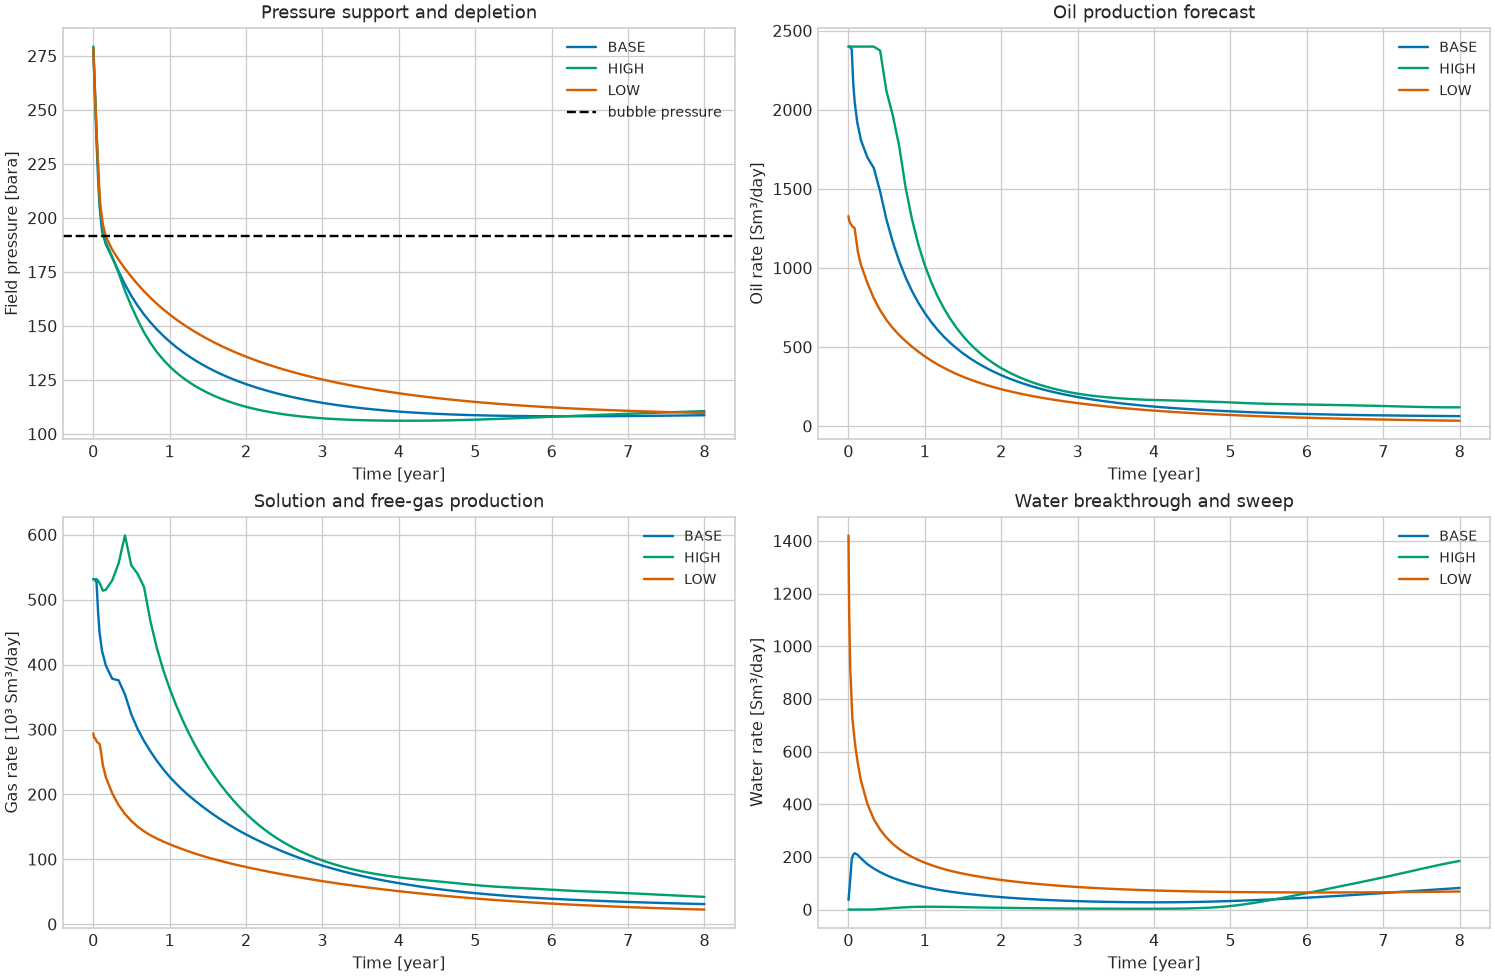

In [34]:
scenario_colors = {
    "LOW": "#D55E00",
    "BASE": "#0072B2",
    "HIGH": "#009E73",
}

forecast_figure, forecast_axes = plt.subplots(
    2,
    2,
    figsize=(13.0, 8.5),
    constrained_layout=True,
)
for case_name, case_history in forecast_history.groupby("scenario"):
    time_year = case_history["time_days"] / 365.25
    line_color = scenario_colors[case_name]
    forecast_axes[0, 0].plot(
        time_year,
        case_history["field_pressure_bara"],
        label=case_name,
        color=line_color,
    )
    forecast_axes[0, 1].plot(
        time_year,
        case_history["oil_rate_Sm3_day"],
        label=case_name,
        color=line_color,
    )
    forecast_axes[1, 0].plot(
        time_year,
        case_history["gas_rate_Sm3_day"] / 1000.0,
        label=case_name,
        color=line_color,
    )
    forecast_axes[1, 1].plot(
        time_year,
        case_history["water_rate_Sm3_day"],
        label=case_name,
        color=line_color,
    )

forecast_axes[0, 0].axhline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="bubble pressure",
)
forecast_axes[0, 0].set_ylabel("Field pressure [bara]")
forecast_axes[0, 0].set_title("Pressure support and depletion")
forecast_axes[0, 0].legend()

forecast_axes[0, 1].set_ylabel("Oil rate [Sm³/day]")
forecast_axes[0, 1].set_title("Oil production forecast")
forecast_axes[0, 1].legend()

forecast_axes[1, 0].set_ylabel("Gas rate [10³ Sm³/day]")
forecast_axes[1, 0].set_title("Solution and free-gas production")
forecast_axes[1, 0].legend()

forecast_axes[1, 1].set_ylabel("Water rate [Sm³/day]")
forecast_axes[1, 1].set_title("Water breakthrough and sweep")
forecast_axes[1, 1].legend()

for forecast_axis in forecast_axes.ravel():
    forecast_axis.set_xlabel("Time [year]")

forecast_plot_path = OUTPUT_DIRECTORY / "opm_flow_production_forecast.png"
forecast_figure.savefig(forecast_plot_path, dpi=170)
plt.show()

In [35]:
forecast_kpi_rows = []
for case_name, case_history in forecast_history.groupby("scenario"):
    cumulative_oil_sm3 = (
        case_history["cumulative_oil_MSm3"].iloc[-1] * 1.0e6
    )
    porosity_multiplier = scenario_table.set_index("scenario").loc[
        case_name,
        "porosity_multiplier",
    ]
    scenario_stoiip_sm3 = initial_oil_in_place_sm3 * porosity_multiplier
    liquid_rate_sm3_day = (
        case_history["oil_rate_Sm3_day"]
        + case_history["water_rate_Sm3_day"]
    )
    field_water_cut = (
        case_history["water_rate_Sm3_day"]
        / liquid_rate_sm3_day.clip(lower=1.0e-12)
    )
    water_breakthrough_rows = case_history.loc[field_water_cut >= 0.10]
    water_breakthrough_year = (
        water_breakthrough_rows["time_days"].iloc[0] / 365.25
        if len(water_breakthrough_rows)
        else np.nan
    )
    forecast_kpi_rows.append(
        {
            "scenario": case_name,
            "screening_STOIIP_MSm3": scenario_stoiip_sm3 / 1.0e6,
            "cumulative_oil_MSm3": cumulative_oil_sm3 / 1.0e6,
            "recovery_factor_fraction": (
                cumulative_oil_sm3 / scenario_stoiip_sm3
            ),
            "water_cut_10pct_year": water_breakthrough_year,
            "final_pressure_bara": case_history[
                "field_pressure_bara"
            ].iloc[-1],
            "peak_oil_rate_Sm3_day": case_history[
                "oil_rate_Sm3_day"
            ].max(),
            "final_water_rate_Sm3_day": case_history[
                "water_rate_Sm3_day"
            ].iloc[-1],
        }
    )

forecast_kpis = pd.DataFrame(forecast_kpi_rows)
display(forecast_kpis)

,scenario,screening_STOIIP_MSm3,cumulative_oil_MSm3,recovery_factor_fraction,water_cut_10pct_year,final_pressure_bara,peak_oil_rate_Sm3_day,final_water_rate_Sm3_day
0,BASE,3.525368,0.909034,0.257855,0.833333,108.709854,2400.000000,82.280731
1,HIGH,3.772144,1.271302,0.337024,5.166667,110.618301,2400.000000,184.856140
2,LOW,3.243339,0.568866,0.175395,0.002738,109.763733,1328.036865,68.781868


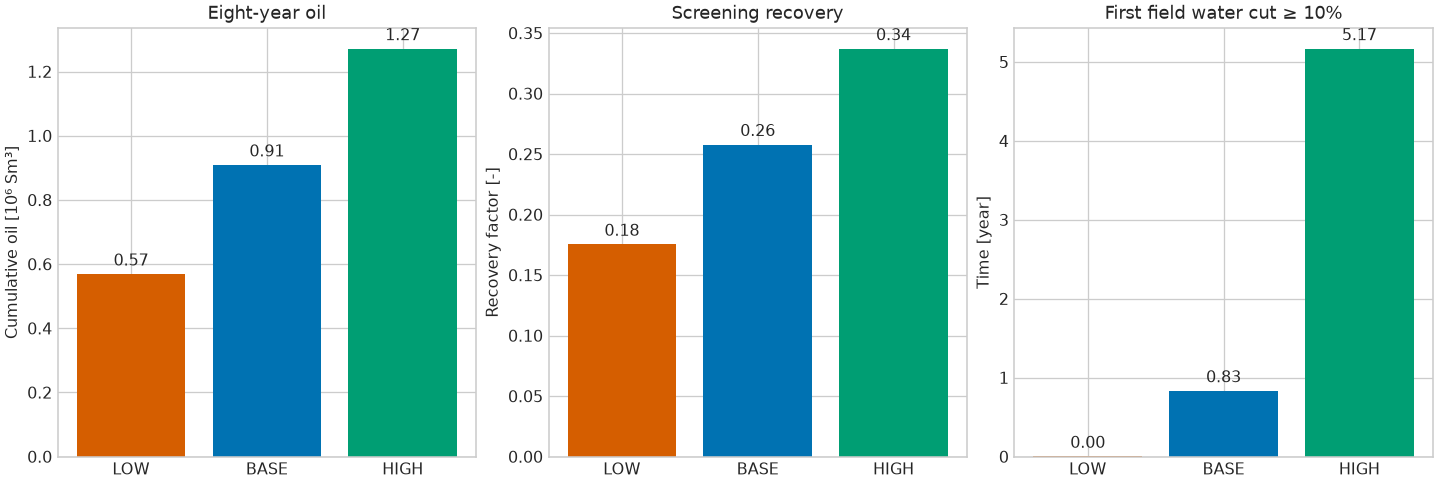

In [36]:
kpi_figure, kpi_axes = plt.subplots(
    1,
    3,
    figsize=(12.5, 4.2),
    constrained_layout=True,
)
ordered_kpis = forecast_kpis.set_index("scenario").loc[
    ["LOW", "BASE", "HIGH"]
].reset_index()
bar_colors = [
    scenario_colors[scenario_name]
    for scenario_name in ordered_kpis["scenario"]
]
oil_bars = kpi_axes[0].bar(
    ordered_kpis["scenario"],
    ordered_kpis["cumulative_oil_MSm3"],
    color=bar_colors,
)
kpi_axes[0].bar_label(oil_bars, fmt="%.2f", padding=3)
kpi_axes[0].set_ylabel("Cumulative oil [10⁶ Sm³]")
kpi_axes[0].set_title("Eight-year oil")

recovery_bars = kpi_axes[1].bar(
    ordered_kpis["scenario"],
    ordered_kpis["recovery_factor_fraction"],
    color=bar_colors,
)
kpi_axes[1].bar_label(recovery_bars, fmt="%.2f", padding=3)
kpi_axes[1].set_ylabel("Recovery factor [-]")
kpi_axes[1].set_title("Screening recovery")

water_cut_bars = kpi_axes[2].bar(
    ordered_kpis["scenario"],
    ordered_kpis["water_cut_10pct_year"],
    color=bar_colors,
)
kpi_axes[2].bar_label(water_cut_bars, fmt="%.2f", padding=3)
kpi_axes[2].set_ylabel("Time [year]")
kpi_axes[2].set_title("First field water cut ≥ 10%")

kpi_plot_path = OUTPUT_DIRECTORY / "forecast_scenario_kpis.png"
kpi_figure.savefig(kpi_plot_path, dpi=170)
plt.show()

## 13. Interpretation of the forecast

The scenarios are not statistical P10/P50/P90 forecasts; they are controlled low/base/high
sensitivities. Their purpose is to make causal effects visible:

- more connected permeability supports rate at a higher BHP;
- a deeper oil-water contact increases hydrocarbon pore volume but can change breakthrough timing;
- porosity changes in-place volume and pressure response; and
- the same well controls can mask subsurface differences during a rate plateau.

The next study step should add multiple facies realizations, structural/contact ensembles, SCAL/PVT
uncertainty and alternative well configurations. The resulting forecast distribution can then be
ranked by cumulative oil, plateau length, water handling, gas handling and economic value.

## 14. Validation strategy

The evidence ladder used here is:

1. OPM's own parser and simulator execute the generated input;
2. SEG-Y and LAS round trips verify file handoffs;
3. NeqSim PVT tables satisfy monotonic simulator contracts;
4. upscaling preserves pore volume;
5. cumulative production is monotonic and rates are non-negative; and
6. low/base/high cases show physically interpretable differences.

This does not replace comparison with measured production, pressure, PLT, 4-D seismic or an
independent simulator. Those are required before an asset forecast can be considered calibrated.

In [37]:
oil_rs_values = oil_table_audit["Rs"].to_numpy()
oil_bubble_pressures = oil_table_audit["pressure"].to_numpy()
gas_pressures = dry_gas_table["pressure_bara"].to_numpy()
gas_bg_values = dry_gas_table["Bg_rm3_Sm3"].to_numpy()

all_forecast_numeric = forecast_history.select_dtypes(
    include=[np.number]
).to_numpy()

validation_checks = {
    "fluid sample closes to 100 mol%": (
        abs(fluid_sample_closure_percent - 100.0) < 1.0e-10
    ),
    "seismic dimensions are complete": (
        recovered_traces.shape
        == (seismic_nx * seismic_ny, seismic_nz)
    ),
    "SEG-Y amplitude round trip closes": (
        np.max(np.abs(recovered_traces - expected_traces)) < 1.0e-6
    ),
    "five LAS files round trip": (
        len(las_roundtrip_audit) == 5
        and (las_roundtrip_audit["curves"] == 6).all()
    ),
    "RCAL permeability fit is informative": core_r2 > 0.75,
    "petrophysical summaries are finite": np.isfinite(
        petrophysical_summary.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all(),
    "SCAL water saturation strictly increases": np.all(
        np.diff(swof_table["Sw"]) > 0.0
    ),
    "SCAL relative permeabilities remain bounded": (
        (
            swof_table[["krw", "kro"]].to_numpy()
            >= 0.0
        ).all()
        and (
            swof_table[["krw", "kro"]].to_numpy()
            <= 1.0
        ).all()
    ),
    "all fine-model properties are finite": np.isfinite(
        np.concatenate(
            [
                fine_porosity.ravel(),
                fine_ntg.ravel(),
                fine_permx_mD.ravel(),
            ]
        )
    ).all(),
    "fine model contains sand and shale": (
        0.05 < fine_facies.mean() < 0.95
    ),
    "upscaling preserves pore volume": (
        abs(pore_volume_error_fraction) < 1.0e-10
    ),
    "saturated Rs strictly increases": (
        np.all(np.diff(oil_rs_values) > 0.0)
    ),
    "PVTO bubble pressure strictly increases": (
        np.all(np.diff(oil_bubble_pressures) > 0.0)
    ),
    "PVDG pressure strictly increases": (
        np.all(np.diff(gas_pressures) > 0.0)
    ),
    "PVDG Bg strictly decreases": (
        np.all(np.diff(gas_bg_values) < 0.0)
    ),
    "all required keywords parse": bool(
        parser_audit["present"].all()
    ),
    "all OPM runs return success": (
        flow_run_audit["return_code"] == 0
    ).all(),
    "all OPM summaries exist": flow_run_audit["SMSPEC_exists"].all(),
    "forecast outputs are finite": np.isfinite(
        all_forecast_numeric
    ).all(),
    "oil, gas and water rates are non-negative": (
        forecast_history[
            [
                "oil_rate_Sm3_day",
                "gas_rate_Sm3_day",
                "water_rate_Sm3_day",
            ]
        ].to_numpy()
        >= -1.0e-8
    ).all(),
    "cumulative oil is non-decreasing": all(
        np.all(
            np.diff(case_frame["cumulative_oil_MSm3"])
            >= -1.0e-10
        )
        for _, case_frame in forecast_history.groupby("scenario")
    ),
    "field pressure changes during forecast": all(
        abs(
            case_frame["field_pressure_bara"].iloc[-1]
            - case_frame["field_pressure_bara"].iloc[0]
        )
        > 0.1
        for _, case_frame in forecast_history.groupby("scenario")
    ),
    "high case has more STOIIP than low case": (
        forecast_kpis.set_index("scenario").loc[
            "HIGH",
            "screening_STOIIP_MSm3",
        ]
        > forecast_kpis.set_index("scenario").loc[
            "LOW",
            "screening_STOIIP_MSm3",
        ]
    ),
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)

failed_checks = validation_table.loc[
    ~validation_table["passed"],
    "check",
].tolist()
if failed_checks:
    raise AssertionError(f"Failed validation checks: {failed_checks}")

print(f"All {len(validation_checks)} validation checks passed.")

,check,passed
0,fluid sample closes to 100 mol%,True
1,seismic dimensions are complete,True
2,SEG-Y amplitude round trip closes,True
3,five LAS files round trip,True
4,RCAL permeability fit is informative,True
5,petrophysical summaries are finite,True
6,SCAL water saturation strictly increases,True
7,SCAL relative permeabilities remain bounded,True
8,all fine-model properties are finite,True
9,fine model contains sand and shale,True


All 23 validation checks passed.


In [38]:
final_results = {
    "notebook": (
        "notebooks/reservoir/"
        "subsurface_data_to_opm_flow_production_forecast.ipynb"
    ),
    "data_basis": "public synthetic teaching data",
    "random_seed": RANDOM_SEED,
    "neqsim_version": version("neqsim"),
    "opm_python_version": version("opm"),
    "opm_flow_version": flow_version_match.group(1),
    "fine_grid_cells": fine_nx * fine_ny * fine_nz,
    "flow_grid_cells": coarse_nx * coarse_ny * coarse_nz,
    "wells": int(len(well_plan)),
    "rock_samples": int(len(core_samples)),
    "scal_samples": int(len(scal_samples)),
    "bubble_pressure_bara": bubble_pressure_bara,
    "base_STOIIP_MSm3": initial_oil_in_place_sm3 / 1.0e6,
    "base_cumulative_oil_MSm3": float(
        forecast_kpis.set_index("scenario").loc[
            "BASE",
            "cumulative_oil_MSm3",
        ]
    ),
    "base_recovery_factor": float(
        forecast_kpis.set_index("scenario").loc[
            "BASE",
            "recovery_factor_fraction",
        ]
    ),
    "validation_checks_passed": int(validation_table["passed"].sum()),
    "validation_checks_total": int(len(validation_table)),
}
final_results_table = pd.DataFrame(
    final_results.items(),
    columns=["result", "value"],
)
display(final_results_table)

results_path = OUTPUT_DIRECTORY / "subsurface_to_opm_manifest.json"
results_path.write_text(
    json.dumps(final_results, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
print(json.dumps(final_results, indent=2, sort_keys=True))
print(f"Run manifest: {results_path}")

,result,value
0,notebook,notebooks/reservoir/subsurface_data_to_opm_flo...
1,data_basis,public synthetic teaching data
2,random_seed,20260728
3,neqsim_version,3.16.0
4,opm_python_version,2026.4
5,opm_flow_version,2026.04
6,fine_grid_cells,10240
7,flow_grid_cells,1280
8,wells,3
9,rock_samples,24


{
  "base_STOIIP_MSm3": 3.5253681478393815,
  "base_cumulative_oil_MSm3": 0.909033625,
  "base_recovery_factor": 0.2578549492929203,
  "bubble_pressure_bara": 191.8290195465088,
  "data_basis": "public synthetic teaching data",
  "fine_grid_cells": 10240,
  "flow_grid_cells": 1280,
  "neqsim_version": "3.16.0",
  "notebook": "notebooks/reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb",
  "opm_flow_version": "2026.04",
  "opm_python_version": "2026.4",
  "random_seed": 20260728,
  "rock_samples": 24,
  "scal_samples": 6,
  "validation_checks_passed": 23,
  "validation_checks_total": 23,
  "wells": 3
}
Run manifest: subsurface_to_opm_outputs/subsurface_to_opm_manifest.json


## Limitations and industrialization path

The notebook proves the complete data contract, but a real reservoir model needs:

1. seismic processing/interpretation uncertainty and depth conversion;
2. reviewed well ties, checkshots, deviation surveys and core-log depth matching;
3. mineralogy-aware petrophysics and saturation-height functions;
4. stress-corrected RCAL and representative restored-state SCAL;
5. PVT regression against measured CCE, DLE, viscosity, density and separator tests;
6. corner-point or unstructured grids with fault transmissibility and aquifers;
7. history matching against rate, pressure, PLT, tracer and 4-D seismic data;
8. ensemble-based uncertainty, alternative well trajectories and operating constraints;
9. wellbore, network, SURF and topside coupling; and
10. economic ranking with decision gates and data-acquisition value.

The existing companion notebook
[`neqsim_opm_flow_blackoil_coupling.ipynb`](neqsim_opm_flow_blackoil_coupling.ipynb)
goes deeper into the OPM-to-NeqSim surface-process handoff. The two notebooks are complementary:
this notebook builds the subsurface model, while the companion extends reservoir results into a
characterized process feed.

## Suggested exercises

1. Replace the synthetic log generator with a public LAS file and retain the sample/data register.
2. Read a public SEG-Y volume with SEGY-SAK and compare at least two horizon-picking methods.
3. Fit a variogram from well or pseudo-well data instead of prescribing its ranges.
4. Generate 30 facies/property realizations and rank them by STOIIP and eight-year oil.
5. Use `pyscal` to create saturation-function ensembles and propagate SCAL uncertainty.
6. Add a fault transmissibility multiplier and quantify compartment-pressure behavior.
7. Optimize producer/injector placement subject to minimum spacing and facility constraints.
8. Connect each Flow forecast to NeqSim wells, SURF and topsides.
9. Add synthetic history, perform assisted history matching and hold out the final year for
   validation.
10. Evaluate the value of one additional appraisal well or SCAL/PVT experiment.

## Reproducibility and scope statement

- The notebook was designed for a clean Ubuntu Google Colab runtime.
- All code cells must execute from top to bottom and retain outputs.
- The exact NeqSim, OPM Python, OPM Flow and helper-library versions are printed near the start.
- All generated files are synthetic and contain no proprietary data.
- The static figures remain visible in the saved notebook.
- Results are educational screening results, not reserves, a history match or a development basis.